In [1]:
import os, sys
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
datasets = ["YAP1", "GFP", "RASK", "PHOT"]
embedding_types = ["otf", "plm", "mpnn"]
models = ["linear", "SVR", "RF", "LGBM", "FFN", "elastic"]
embeddings = ["OHE", "BL90", "BL50","georgiev", "ESMC", "ProstT5", "MPNN"]

nStarts = [100,200,500,1000,3000]
nGains = [10,20,50,100]
target_mutants = {
"YAP1": ['D170Q:S183R', 'D170K:D194N'],
"GFP":  ['K3R:G4S:L178H:Q184R', 'K3E:T230S', 'E5V:N121S:K140R', 'E5D:T9A:I171T', 'E6K:D76N:N105Y', 'F8L:D19N:N105Y:I171V', 'F8L:Q80R', 'T9A:I171V', 'V11A:D173N:S202I', 'I14V:T43A', 'L15M:M153V', 'H25R:I167V:G191S:N198D', 'H25R:E124K:K156R', 'H25Q:T59S:I171T', 'S28R:T97A:K107Q:I188V', 'E32G:E132A', 'E34A:T38S:T62A:V68M:I171T', 'T38A:K52R:N159D:K162E', 'T38N:S202R', 'T38S:K41R:N105S', 'Y39H:N146D', 'Y39H:N135S', 'Y39H:F99S:K126R:I171V', 'Y39N:N105I', 'Y39N:K158R', 'Y39N:T62A:Q157R', 'K41R:K158E:M233V', 'T43S:K107R:Q157H', 'T43S:K156E:K166R:I171V', 'T43S:D180N', 'F46Y:I47V', 'I47V:I161V', 'T62A:E111V:I161L', 'T62A:K131E:N170D', 'V68M:K131R:N159D:Q184R', 'F71L:E90G:K166E:N212D', 'S72G:N105S:Y182C:T230P', 'S72G:T203I:L236Q', 'R73L', 'D76V:H81L', 'D76G:I128T', 'H77Y:T97A', 'A87T:K158R:I171L', 'E90G:K158R:N198D', 'E90D:F99C:N146D:Q177L', 'E90A:V163A:N164S:N198D:N212S', 'T97A:N105Y:T225A', 'K101R:D180E:S205T', 'K101R:K214E', 'N105Y:G174S', 'Y106F:K113R:N198S', 'K107R:V163G:N212S', 'E111V:V176A:A227T', 'N121S:M153T:I171V', 'I128V:N146D', 'I128T:K158E', 'D129G:M233V', 'K131R:N170S', 'N135D:T203I', 'E142V:Q177L', 'N146S:K156E:K214E', 'S147N:T230P', 'K156E:Q184L', 'Q157R:G191S:V219L', 'K158G', 'K158R:N198D:K214E', 'K158R:Q184L', 'K158R:K162R:I171T:K214R', 'I161V:K166R', 'V163A:N164D:E172G:K214E', 'V163A:F223Y:I229V', 'V163A:V176A:Y182C:Q184R', 'V163A:S175R', 'V163E:Q184L', 'I171V:Q204L:L236V', 'S175T', 'Q184R:T186A', 'P192H:V193A:K214N'],
"RASK": ['A66P:H95N', 'A66P:R68M', 'R149V:I187P'],
"PHOT": ['R59D']
}

In [3]:
combination_colors = {
    # blosum50 — Red family (H=0°)
    'ProstT5 x elastic': 'rgba(153,   0,   0, 1)',      # dark red
    'ProstT5 x FFN':     'rgba(230,   0,   0, 0.9)',    # pure red
    'ProstT5 x LGBM':    'rgba(255, 102, 102, 0.8)',    # light red
    'ProstT5 x linear':  'rgba(179,  51,  51, 0.7)',    # muted dark red
    'ProstT5 x RF':      'rgba(217,  77,  77, 0.6)',    # mid muted red
    'ProstT5 x SVR':     'rgba(255, 179, 179, 0.5)',    # pale red/pink

    # blosum90 — Orange/Amber family (H=45°)
    'BL90 x elastic':    'rgba(153, 102,   0, 1)',      # dark amber
    'BL90 x FFN':        'rgba(230, 153,   0, 0.9)',    # amber
    'BL90 x LGBM':       'rgba(255, 204,  77, 0.8)',    # light amber
    'BL90 x linear':     'rgba(179, 128,  51, 0.7)',    # muted dark amber
    'BL90 x RF':         'rgba(217, 166,  77, 0.6)',    # mid muted amber
    'BL90 x SVR':        'rgba(255, 230, 93, 0.5)',    # pale amber

    # esmc_600m — Yellow-Green family (H=90°)
    'ESMC x elastic':    'rgba( 51, 128,   0, 1)',      # dark yellow-green
    'ESMC x FFN':        'rgba( 77, 204,   0, 0.9)',    # yellow-green
    'ESMC x LGBM':       'rgba(128, 255,  64, 0.8)',    # light chartreuse
    'ESMC x linear':     'rgba( 77, 153,  51, 0.7)',    # muted dark green
    'ESMC x RF':         'rgba(115, 204,  77, 0.6)',    # mid muted green
    'ESMC x SVR':        'rgba(179, 255, 153, 0.5)',    # pale green

    # georgiev — Teal/Spring-Green family (H=160°)
    'georgiev x elastic': 'rgba(  0, 128,  77, 1)',      # dark teal
    'georgiev x FFN':     'rgba(  0, 204, 128, 0.9)',    # spring green
    'georgiev x LGBM':    'rgba( 77, 255, 179, 0.8)',    # light mint
    'georgiev x linear':  'rgba( 51, 153, 102, 0.7)',    # muted dark teal
    'georgiev x RF':      'rgba( 77, 204, 153, 0.6)',    # mid muted teal
    'georgiev x SVR':     'rgba(133, 230, 169, 0.5)',    # pale seafoam (green-teal, not blue)

    # mpnn_probs — Violet/Indigo family (H=260°)
    'MPNN x elastic':    'rgba( 51,   0, 128, 1)',      # dark indigo
    'MPNN x FFN':        'rgba( 77,   0, 204, 0.9)',    # indigo
    'MPNN x LGBM':       'rgba(128,  77, 255, 0.8)',    # light violet
    'MPNN x linear':     'rgba( 77,  51, 153, 0.7)',    # muted dark indigo
    'MPNN x RF':         'rgba(115,  77, 204, 0.6)',    # mid muted violet
    'MPNN x SVR':        'rgba(204, 179, 255, 0.5)',    # pale violet

    # one_hot — Azure/Blue family (H=210°)
    'OHE x elastic':     'rgba(  0,  77, 128, 1)',      # dark azure
    'OHE x FFN':         'rgba(  0, 128, 204, 0.9)',    # azure
    'OHE x LGBM':        'rgba( 77, 179, 255, 0.8)',    # sky blue
    'OHE x linear':      'rgba( 51, 102, 153, 0.7)',    # muted dark azure
    'OHE x RF':          'rgba( 77, 153, 204, 0.6)',    # mid muted azure
    'OHE x SVR':         'rgba(179, 217, 255, 0.5)',    # pale azure

    # prost_t5 — Magenta/Rose family (H=320°)
    'BL50 x elastic':    'rgba(128,   0, 102, 1)',      # dark magenta
    'BL50 x FFN':        'rgba(204,   0, 179, 0.9)',    # magenta
    'BL50 x LGBM':       'rgba(255,  77, 230, 0.8)',    # light magenta
    'BL50 x linear':     'rgba(153,  51, 128, 0.7)',    # muted dark magenta
    'BL50 x RF':         'rgba(204,  77, 179, 0.6)',    # mid muted magenta
    'BL50 x SVR':        'rgba(255, 179, 242, 0.5)',    # pale rose
}


In [4]:
date = datetime.now().strftime("%d%m%Y")

In [5]:
# Load runs_df from saved CSV file
old_save_state = True


if not old_save_state:
    file_name = f"runs_results_{date}.csv"
    
else:
    date = "05052026"
    file_name = f"runs_results_{date}.csv"
runs_df = pd.read_csv(file_name)

# Replace specific model and embedding names
runs_df = runs_df.replace({
    "fnn": "FFN",
    "rf": "RF",
    "one_hot": "OHE",
    "svr": "SVR",
    "blosum50": "BL50",
    "blosum90": "BL90",
    "mpnn_probs": "MPNN",
    "lightgbm": "LGBM",
    "esmc_600m": "ESMC",   
    "elastic_net": "elastic",
    "prost_t5": "ProstT5",

    
})


In [6]:
print(runs_df)

                                                  run_id    status   result  \
0      GFP_blosum50_rf_nGain20_nStart1000_ddG_top_sta...  finished  success   
1      RASK_one_hot_elastic_net_nGain100_nStart200_dd...  finished  success   
2      GFP_georgiev_fnn_nGain50_nStart500_ddG_top_sta...  finished  success   
3      GFP_one_hot_elastic_net_nGain100_nStart3000_dd...  finished  success   
4      GFP_georgiev_fnn_nGain20_nStart200_ddG_top_sta...  finished  failure   
...                                                  ...       ...      ...   
32249  YAP1_mpnn_probs_svr_nGain100_nStart500_ddG_top...  finished  failure   
32250  YAP1_mpnn_probs_linear_nGain10_nStart1000_ddG_...  finished  failure   
32251  GFP_mpnn_probs_linear_nGain100_nStart3000_ddG_...  finished  success   
32252  RASK_mpnn_probs_elastic_net_nGain20_nStart3000...  finished  success   
32253  GFP_mpnn_probs_rf_nGain10_nStart3000_ddG_top_s...   running     open   

      dataset    model embedding  n_Gain  n_Start  

In [7]:
# Create pivot table: embeddings (rows) x models (columns) showing completion ratio
# Total runs per combination: 800

# Count finished runs per embedding-model combination
finished_counts = runs_df[runs_df['status'] == 'finished'].groupby(['embedding', 'model']).size()

# Convert to dataframe and calculate ratio
n_total_per_ensemble = 4 * 10 * 5 * 4 # for each embedding-model combination 800 potential runs exist (4 datasets x 10 runs x 5 n_Start x 4 n_Gain combinations)
completion_data = finished_counts.reset_index(name='finished_count')
completion_data['completion_ratio'] = round(completion_data['finished_count'] / n_total_per_ensemble, 2)

# Pivot to get embeddings as rows and models as columns
completion_pivot = completion_data.pivot(index='embedding', columns='model', values='completion_ratio')

print("Completion Rate by Embedding (rows) and Model (columns):")
print("="*80)
print(completion_pivot)
print("\nColumn Averages (by model):")
print(round(completion_pivot.mean(axis=0), 2))
print("\nRow Averages (by embedding):")
print(round(completion_pivot.mean(axis=1), 2))
print(f"\nTotal Average across all combinations: {completion_pivot.mean().mean():.2f}")
print("\nNote: Values represent the ratio of finished runs out of 800 total runs per combination")

Completion Rate by Embedding (rows) and Model (columns):
model       FFN  LGBM    RF   SVR  elastic  linear
embedding                                         
BL50       0.95  0.97  0.91  0.84     0.97    0.98
BL90       0.95  0.97  0.92  0.83     0.96    0.96
ESMC       1.00  1.00  0.81  0.68     0.99    0.99
MPNN       0.80  0.80  0.38  0.73     0.80    0.80
OHE        0.95  0.97  0.94  0.98     0.96    0.96
ProstT5     NaN  0.98  0.85  0.98     0.98    0.89
georgiev   0.95  0.97  0.92  0.97     0.96    0.96

Column Averages (by model):
model
FFN        0.93
LGBM       0.95
RF         0.82
SVR        0.86
elastic    0.95
linear     0.93
dtype: float64

Row Averages (by embedding):
embedding
BL50        0.94
BL90        0.93
ESMC        0.91
MPNN        0.72
OHE         0.96
ProstT5     0.94
georgiev    0.96
dtype: float64

Total Average across all combinations: 0.91

Note: Values represent the ratio of finished runs out of 800 total runs per combination


In [8]:
# Calculate success ratio and average successful duration for each grouping
print("Evaluation per single dimension")
print("  how many runs were successful in total")
print()
groups = ["dataset", "model", "embedding", "n_Start", "n_Gain"]
for grouping in groups:
    success_counts = runs_df[runs_df['result'] == 'success'].groupby([grouping]).size()
    finished_counts = runs_df[runs_df['status'] == 'finished'].groupby([grouping]).size()
    success_ratio = round(success_counts / finished_counts, 3).sort_values(ascending=False)
    
    successful_finished_df = runs_df[
        (runs_df['status'] == 'finished') & (runs_df['result'] == 'success')
    ]
    avg_success_duration = successful_finished_df.groupby(grouping)['last_cycle'].mean()
    
    print(grouping)
    print("=" * 80)
    for result in success_ratio.index:
        criterium = result
        ratio = success_ratio[result]
        avg_duration = avg_success_duration.get(criterium, float('nan'))
        if pd.notna(avg_duration):
            print(f" -{criterium} | Success Ratio: {ratio} | Avg Duration (successful finished runs): {avg_duration:.2f}")
        else:
            print(f" -{criterium} | Success Ratio: {ratio} | Avg Duration (successful finished runs): n/a")
    print("\n")


Evaluation per single dimension
  how many runs were successful in total

dataset
 -GFP | Success Ratio: 0.799 | Avg Duration (successful finished runs): 5.79
 -YAP1 | Success Ratio: 0.617 | Avg Duration (successful finished runs): 7.29
 -RASK | Success Ratio: 0.574 | Avg Duration (successful finished runs): 6.96
 -PHOT | Success Ratio: 0.076 | Avg Duration (successful finished runs): 11.92


model
 -RF | Success Ratio: 0.625 | Avg Duration (successful finished runs): 7.58
 -SVR | Success Ratio: 0.568 | Avg Duration (successful finished runs): 5.85
 -elastic | Success Ratio: 0.536 | Avg Duration (successful finished runs): 6.67
 -LGBM | Success Ratio: 0.512 | Avg Duration (successful finished runs): 6.31
 -linear | Success Ratio: 0.483 | Avg Duration (successful finished runs): 6.48
 -FFN | Success Ratio: 0.387 | Avg Duration (successful finished runs): 8.34


embedding
 -ProstT5 | Success Ratio: 0.67 | Avg Duration (successful finished runs): 7.11
 -BL90 | Success Ratio: 0.553 | Avg D

In [9]:
# Calculate success ratio for each dataset
# which algorithm finishes best within the first cycles
max_cycles = [5]
top_n = 5

for max_cycle in max_cycles:
    last_cycle = max_cycle
    
    print(f"Who finishes best, only taking {last_cycle} {('cycle' if last_cycle == 1 else 'cycles')}:")
    print(" - Evaluation per model and embedding - with 100 starting points")
    print("="*80)

    for dataset in datasets:
        filtered_df = runs_df[(runs_df['dataset'] == dataset) & (runs_df['n_Start'] == 100)]
        
        success_counts = filtered_df[(filtered_df['result'] == 'success') &
                                    (filtered_df['last_cycle'] <= last_cycle)].groupby(["model", "embedding"]).size()
        finished_counts = filtered_df[filtered_df['status'] == 'finished'].groupby(["model", "embedding"]).size()

        finished_within_1_round = round(success_counts/finished_counts,3).sort_values(ascending=False)

        print(f"\n Dataset: {dataset} - Top {top_n}")
        for result in finished_within_1_round.index[:top_n]:  # show top {top_n} results
            model, embedding = result
            ratio = finished_within_1_round[result]
            if ratio >0:
                print(f"  Model: {model} | Embedding: {embedding} | Success Ratio within {last_cycle} cycles: {ratio}")
    print("\n")

Who finishes best, only taking 5 cycles:
 - Evaluation per model and embedding - with 100 starting points

 Dataset: YAP1 - Top 5
  Model: linear | Embedding: OHE | Success Ratio within 5 cycles: 0.65
  Model: linear | Embedding: georgiev | Success Ratio within 5 cycles: 0.625
  Model: elastic | Embedding: georgiev | Success Ratio within 5 cycles: 0.6
  Model: linear | Embedding: BL90 | Success Ratio within 5 cycles: 0.55
  Model: LGBM | Embedding: BL90 | Success Ratio within 5 cycles: 0.525

 Dataset: GFP - Top 5
  Model: SVR | Embedding: georgiev | Success Ratio within 5 cycles: 0.65
  Model: RF | Embedding: ProstT5 | Success Ratio within 5 cycles: 0.625
  Model: SVR | Embedding: BL90 | Success Ratio within 5 cycles: 0.6
  Model: SVR | Embedding: BL50 | Success Ratio within 5 cycles: 0.55
  Model: SVR | Embedding: ProstT5 | Success Ratio within 5 cycles: 0.55

 Dataset: RASK - Top 5
  Model: RF | Embedding: ProstT5 | Success Ratio within 5 cycles: 0.925
  Model: LGBM | Embedding: ESM

In [10]:
# Calculate success ratios for each combination
success_counts = runs_df[runs_df['result'] == 'success'].groupby(["dataset", "n_Start", "n_Gain", "embedding", "model"]).size()
finished_counts = runs_df[runs_df['status'] == 'finished'].groupby(["dataset", "n_Start", "n_Gain", "embedding", "model"]).size()

ratio = (success_counts / finished_counts).fillna(0)

# Only include runs that finished at least 4 times for that combination
ratio = ratio[finished_counts >= 5].reset_index(name='success_ratio')

# Find the best performing embedding-model combination for each (dataset, n_Start, n_Gain)
idx = ratio.groupby(['dataset', 'n_Start', 'n_Gain'])['success_ratio'].idxmax()
best_ratios = ratio.loc[idx]

# Additionally we might want to include the model/embedding names in the output table, but for now just the success ratio as requested.
# Formatting n_Start and n_Gain as a single string for row names
best_ratios['n_Start_Gain'] = best_ratios['n_Start'].astype(str) + '_' + best_ratios['n_Gain'].astype(str)

# Pivot table: Columns=datasets, Rows=n_Start_Gain combinations
pivot_table = best_ratios.pivot(index=['n_Start', 'n_Gain'], columns='dataset', values='success_ratio')

print("Best performing embedding-model combination's success ratio:")
display(pivot_table)

Best performing embedding-model combination's success ratio:


dataset         GFP  PHOT  RASK  YAP1
n_Start n_Gain                       
100     10      1.0  0.30   1.0   1.0
        20      1.0  0.50   1.0   1.0
        50      1.0  0.75   1.0   1.0
        100     1.0  1.00   1.0   1.0
200     10      1.0  0.30   1.0   1.0
        20      1.0  0.60   1.0   1.0
        50      1.0  1.00   1.0   1.0
        100     1.0  1.00   1.0   1.0
500     10      1.0  0.30   1.0   1.0
        20      1.0  1.00   1.0   1.0
        50      1.0  1.00   1.0   1.0
        100     1.0  1.00   1.0   1.0
1000    10      1.0  0.10   1.0   1.0
        20      1.0  1.00   1.0   0.9
        50      1.0  1.00   1.0   1.0
        100     1.0  1.00   1.0   1.0
3000    10      1.0  0.20   1.0   1.0
        20      1.0  0.25   1.0   1.0
        50      1.0  1.00   1.0   1.0
        100     1.0  1.00   1.0   1.0

In [11]:
# We want to show: Success ratio, average duration of successful runs, and the model-embedding combination.
successful_runs = runs_df[runs_df['result'] == 'success']
# Assuming we want the average duration for these successful runs using 'last_cycle'
avg_durations = successful_runs.groupby(["dataset", "n_Start", "n_Gain", "embedding", "model"])['last_cycle'].mean().reset_index(name='avg_duration')

# Merge the success ratio and avg_durations
combo_df = pd.merge(ratio, avg_durations, on=["dataset", "n_Start", "n_Gain", "embedding", "model"], how='left')

# Only include runs that finished at least 4 times for that combination
finished_counts_df = runs_df[runs_df['status'] == 'finished'].groupby(["dataset", "n_Start", "n_Gain", "embedding", "model"]).size().reset_index(name='finished_counts')
combo_df = pd.merge(combo_df, finished_counts_df, on=["dataset", "n_Start", "n_Gain", "embedding", "model"], how='left')
combo_df = combo_df[combo_df['finished_counts'] >= 4]

# To break ties in favor of prost_t5 x rf, we can create a custom sorting key. 
# We'll add a boolean column `is_prost_t5_rf` that is True when the combination is 'prost_t5' and 'rf'.
# When sorting, `is_prost_t5_rf = False` comes before `True` inherently if ascending, so we'll sort it descending
# to prioritize True values when success_ratio and avg_duration are equal.
combo_df['is_prost_t5_rf'] = (combo_df['embedding'] == 'prost_t5') & (combo_df['model'] == 'rf')

# Sort values by success_ratio (descending), avg_duration (ascending), and is_prost_t5_rf (descending)
combo_df = combo_df.sort_values(by=['dataset', 'n_Start', 'n_Gain', 'success_ratio', 'avg_duration', 'is_prost_t5_rf'], 
                                ascending=[True, True, True, False, True, False])

# Keep the first row per group, which is the best one due to the sorting
best_combo = combo_df.drop_duplicates(subset=['dataset', 'n_Start', 'n_Gain']).copy()

# Remove the temporary column
best_combo = best_combo.drop(columns=['is_prost_t5_rf'])

# Create a formatted string for each cell: "Ratio | Duration | Embd-Model"
best_combo['formatted_value'] = (
    (best_combo['success_ratio'] * 100).round(1).astype(str) + "% | " +
    best_combo['avg_duration'].round(1).astype(str) + " cyc | " +
    best_combo['embedding'] + "-" + best_combo['model']
)

pivot_table_rich = best_combo.pivot(index=['n_Start', 'n_Gain'], columns='dataset', values='formatted_value')
display(pivot_table_rich)

dataset                                        GFP  \
n_Start n_Gain                                       
100     10         100.0% | 9.4 cyc | georgiev-SVR   
        20           100.0% | 4.4 cyc | ProstT5-RF   
        50         100.0% | 2.7 cyc | ProstT5-LGBM   
        100         100.0% | 2.2 cyc | OHE-elastic   
200     10           100.0% | 9.6 cyc | ProstT5-RF   
        20           100.0% | 3.9 cyc | ProstT5-RF   
        50           100.0% | 2.0 cyc | ProstT5-RF   
        100          100.0% | 1.6 cyc | ProstT5-RF   
500     10           100.0% | 4.7 cyc | ProstT5-RF   
        20             100.0% | 2.4 cyc | BL50-SVR   
        50           100.0% | 1.9 cyc | ProstT5-RF   
        100     100.0% | 1.5 cyc | georgiev-linear   
1000    10           100.0% | 4.4 cyc | ProstT5-RF   
        20          100.0% | 2.1 cyc | georgiev-RF   
        50           100.0% | 1.8 cyc | ProstT5-RF   
        100          100.0% | 1.2 cyc | ProstT5-RF   
3000    10         100.0% | 1.8 cyc | georgiev-SVR   
        20         100.0% | 1.2 cyc | georgiev-SVR   
        50             100.0% | 1.0 cyc | BL50-SVR   
        100            100.0% | 1.0 cyc | BL50-SVR   

dataset                                        PHOT  \
n_Start n_Gain                                        
100     10            30.0% | 24.0 cyc | ProstT5-RF   
        20            50.0% | 20.6 cyc | ProstT5-RF   
        50             75.0% | 6.5 cyc | ProstT5-RF   
        100         100.0% | 19.0 cyc | ESMC-linear   
200     10      30.0% | 11.7 cyc | georgiev-elastic   
        20            60.0% | 13.0 cyc | ProstT5-RF   
        50             100.0% | 9.6 cyc | ESMC-LGBM   
        100            100.0% | 6.2 cyc | ESMC-LGBM   
500     10      30.0% | 14.7 cyc | georgiev-elastic   
        20           100.0% | 18.9 cyc | ProstT5-RF   
        50            100.0% | 9.0 cyc | ProstT5-RF   
        100           100.0% | 6.4 cyc | ProstT5-RF   
1000    10            10.0% | 23.0 cyc | ProstT5-RF   
        20           100.0% | 18.0 cyc | ProstT5-RF   
        50            100.0% | 8.9 cyc | ProstT5-RF   
        100           100.0% | 5.3 cyc | ProstT5-RF   
3000    10       20.0% | 6.5 cyc | georgiev-elastic   
        20        25.0% | 35.5 cyc | ProstT5-linear   
        50      100.0% | 5.5 cyc | georgiev-elastic   
        100           100.0% | 4.8 cyc | ProstT5-RF   

dataset                                    RASK  \
n_Start n_Gain                                    
100     10        100.0% | 4.6 cyc | ProstT5-RF   
        20        100.0% | 2.6 cyc | ProstT5-RF   
        50      100.0% | 2.1 cyc | ProstT5-LGBM   
        100     100.0% | 1.3 cyc | ProstT5-LGBM   
200     10        100.0% | 4.2 cyc | ProstT5-RF   
        20        100.0% | 2.0 cyc | ProstT5-RF   
        50        100.0% | 1.1 cyc | ProstT5-RF   
        100       100.0% | 1.0 cyc | ProstT5-RF   
500     10        100.0% | 4.2 cyc | ProstT5-RF   
        20        100.0% | 1.5 cyc | ProstT5-RF   
        50        100.0% | 1.0 cyc | ProstT5-RF   
        100       100.0% | 1.1 cyc | ProstT5-RF   
1000    10        100.0% | 3.8 cyc | ProstT5-RF   
        20        100.0% | 2.5 cyc | ProstT5-RF   
        50          100.0% | 1.0 cyc | ESMC-SVR   
        100       100.0% | 1.0 cyc | ProstT5-RF   
3000    10        100.0% | 1.0 cyc | ProstT5-RF   
        20           100.0% | 1.0 cyc | ESMC-RF   
        50           100.0% | 1.0 cyc | ESMC-RF   
        100     100.0% | 1.0 cyc | BL90-elastic   

dataset                                        YAP1  
n_Start n_Gain                                       
100     10      100.0% | 7.2 cyc | georgiev-elastic  
        20               100.0% | 4.2 cyc | OHE-SVR  
        50       100.0% | 4.4 cyc | georgiev-linear  
        100              100.0% | 1.8 cyc | OHE-SVR  
200     10       100.0% | 3.5 cyc | georgiev-linear  
        20           100.0% | 3.7 cyc | OHE-elastic  
        50               100.0% | 4.8 cyc | O

In [87]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os

best_combo_excl_YAP1 = best_combo[best_combo['dataset'] != 'YAP1']

# ============================================================================
# HELPER
# ============================================================================
def get_contrast_color(col_str):
    col_str = str(col_str).strip()
    r, g, b = 255, 255, 255

    if col_str.startswith('#'):
        hx = col_str.lstrip('#')
        if len(hx) == 3:
            hx = ''.join(c*2 for c in hx)
        if len(hx) >= 6:
            try:
                r, g, b = tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))
            except:
                pass

    elif col_str.startswith('rgb'):
        vals = [int(v) for v in re.findall(r'\d+', col_str)]
        if len(vals) >= 3:
            r, g, b = vals[0], vals[1], vals[2]

    lum = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    is_dark = lum < 0.5
    is_blue = b > r and b >= g

    return 'white' if (is_dark and is_blue) else 'black'


# ============================================================================
# DATA PREP
# ============================================================================
best_combo_excl_YAP1['combo_name'] = (
    best_combo_excl_YAP1['embedding'].astype(str).str.strip()
    + " x " +
    best_combo_excl_YAP1['model'].astype(str).str.strip()
)

pivot_text = best_combo_excl_YAP1.pivot(
    index=['n_Gain', 'n_Start'],
    columns='dataset',
    values='formatted_value'
)

pivot_combo = best_combo_excl_YAP1.pivot(
    index=['n_Gain', 'n_Start'],
    columns='dataset',
    values='combo_name'
)


y_labels_rich = [f"{start} | {gain}" for gain, start in pivot_text.index]
x_labels_rich = pivot_text.columns.tolist()


# ============================================================================
# UNIQUE COMBOS (SAFE)
# ============================================================================
unique_combos = np.unique(
    [x.strip() for x in pivot_combo.values.flatten() if pd.notna(x)]
)

sorted_unique_combos = sorted(unique_combos, key=lambda x: tuple(x.split(' x ')))
combo_to_int = {combo: i for i, combo in enumerate(sorted_unique_combos)}


# ============================================================================
# Z MATRIX
# ============================================================================
z_vals = np.zeros(pivot_combo.shape)

for i in range(pivot_combo.shape[0]):
    for j in range(pivot_combo.shape[1]):

        combo = pivot_combo.iloc[i, j]

        if pd.isna(combo):
            z_vals[i, j] = np.nan
        else:
            z_vals[i, j] = combo_to_int.get(combo.strip(), np.nan)


# ============================================================================
# COLORSCALE
# ============================================================================
n_colors = len(sorted_unique_combos)
colorscale_dynamic = []

for i, combo in enumerate(sorted_unique_combos):
    color = combination_colors.get(combo, 'rgba(128,128,128,0.8)')
    colorscale_dynamic.append([i / n_colors, color])
    colorscale_dynamic.append([(i + 1) / n_colors, color])


# ============================================================================
# HEATMAP
# ============================================================================
fig_rich = go.Figure(data=go.Heatmap(
    z=z_vals,
    x=x_labels_rich,
    y=y_labels_rich,
    hovertext=pivot_text.values,
    colorscale=colorscale_dynamic,
    zmin=0,
    zmax=n_colors,
    showscale=False,
    hoverinfo="text",
))


# ============================================================================
# ANNOTATIONS (TRUE LEFT CELL ALIGNMENT FIX)
# ============================================================================
annotations = []

for i in range(pivot_combo.shape[0]):
    for j in range(pivot_combo.shape[1]):

        val = pivot_text.iloc[i, j]
        combo = pivot_combo.iloc[i, j]

        if not pd.isna(val):

            base_text = val
            bg_color = combination_colors.get(combo, 'white') if not pd.isna(combo) else 'white'
            text_color = get_contrast_color(bg_color)

            success = int(float(base_text.split('|')[0].strip(" %").strip()))
            duration = float(base_text.split('|')[1].strip(" cyc").replace(',', '.'))
            combo_name = base_text.split('|')[2].strip()

            # ----------------------------
            # FORMATTING (your rules kept)
            # ----------------------------
            success_str = f" {success:>3d}%" if success < 100 else f"{success:>3d}%"
            duration_str = f"{duration:>4.1f} cyc" if duration < 10 else f"{round(duration):>4d} cyc"

            formatted_text = f"{success_str} | {duration_str} | {combo_name}"

            # ----------------------------
            # KEY FIX: shift inside cell
            # ----------------------------
            annotations.append(dict(
                x=j - 0.36,   # IMPORTANT: left-align inside cell
                y=i,
                xref="x",
                yref="y",
                text=formatted_text,
                xanchor="left",
                yanchor="middle",
                align="left",
                showarrow=False,
                font=dict(
                    color=text_color,
                    size=20
                )
            ))


# ============================================================================
# LAYOUT
# ============================================================================
fig_rich.update_layout(
    annotations=annotations,
    height=800,
    width=1500,
    xaxis_title="Library",
    yaxis_title="nStart | nGain",
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend_title_text='Winning Combination',
    legend=dict(font=dict(size=20)),
)


# ============================================================================
# LEGEND
# ============================================================================
for combo in sorted_unique_combos:
    color = combination_colors.get(combo, 'rgba(128, 128, 128, 0.8)')
    fig_rich.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(color=color, symbol='square', size=30),
        name=combo,
        legendgroup=combo,
        showlegend=False
    ))


# ============================================================================
# AXES
# ============================================================================
fig_rich.update_yaxes(
    autorange="reversed",
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    mirror=True,
    title_font=dict(size=20),
    tickfont=dict(size=20)
)

fig_rich.update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    mirror=True,
    title_font=dict(size=20),
    tickfont=dict(size=20)
)


# ============================================================================
# GRID LINES
# ============================================================================
for i in range(len(x_labels_rich) - 1):
    fig_rich.add_vline(x=i + 0.5, line_width=1, line_color='black')

for i in range(len(pivot_text.index) - 1):
    curr_ngain = pivot_text.index[i][0]
    next_ngain = pivot_text.index[i + 1][0]

    lw = 3 if curr_ngain != next_ngain else 1

    fig_rich.add_hline(y=i + 0.5, line_width=lw, line_color='black')

    if lw == 3:
        fig_rich.add_shape(
            type="line",
            x0=-0.1, x1=0,
            y0=i + 0.5, y1=i + 0.5,
            line=dict(color="black", width=lw),
            xref="paper",
            yref="y"
        )


# ============================================================================
# OUTPUT
# ============================================================================
fig_rich.show()

outpath = "plots/"
title = "top_combinations_detailled_excl_YAP1.jpg"

fig_rich.write_image(
    os.path.join(outpath, title),
    scale=2
)

/tmp/ipykernel_41025/3300866288.py:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# We want to show: Success ratio and average duration of successful runs, specifically for the combination ProstT5 and rf.

# Filter the data specifically for ProstT5 and rf regressor combo
prostt5_rf_combo = combo_df[(combo_df['embedding'] == 'ProstT5') & 
                            (combo_df['model'] == 'RF')].copy()

if len(prostt5_rf_combo) == 0:
    print("Warning: No matching rows found for ProstT5 and RF.")
else:
    # Create a formatted string for each cell: "Ratio | Duration"
    prostt5_rf_combo['formatted_value'] = (
        (prostt5_rf_combo['success_ratio'] * 100).round(1).astype(str) + "% | " +
        prostt5_rf_combo['avg_duration'].round(1).astype(str) + " cyc"
    )

    pivot_table_prostt5_rf = prostt5_rf_combo.pivot(index=['n_Start', 'n_Gain'], columns='dataset', values='formatted_value')

    print("Performance of ProstT5 with RF (Success Ratio | Duration):")
    display(pivot_table_prostt5_rf)

Performance of ProstT5 with RF (Success Ratio | Duration):


dataset                      GFP               PHOT              RASK  \
n_Start n_Gain                                                          
100     10      70.0% | 10.1 cyc   30.0% | 24.0 cyc  100.0% | 4.6 cyc   
        20      100.0% | 4.4 cyc   50.0% | 20.6 cyc  100.0% | 2.6 cyc   
        50      100.0% | 3.9 cyc    75.0% | 6.5 cyc  100.0% | 4.2 cyc   
        100     100.0% | 2.2 cyc    90.0% | 9.2 cyc  100.0% | 1.3 cyc   
200     10      100.0% | 9.6 cyc   20.0% | 19.5 cyc  100.0% | 4.2 cyc   
        20      100.0% | 3.9 cyc   60.0% | 13.0 cyc  100.0% | 2.0 cyc   
        50      100.0% | 2.0 cyc   88.9% | 10.0 cyc  100.0% | 1.1 cyc   
        100     100.0% | 1.6 cyc   100.0% | 7.6 cyc  100.0% | 1.0 cyc   
500     10      100.0% | 4.7 cyc   30.0% | 21.7 cyc  100.0% | 4.2 cyc   
        20      100.0% | 5.5 cyc  100.0% | 18.9 cyc  100.0% | 1.5 cyc   
        50      100.0% | 1.9 cyc   100.0% | 9.0 cyc  100.0% | 1.0 cyc   
        100     100.0% | 1.6 cyc   100.0% | 6.4 cyc  100.0% | 1.1 cyc   
1000    10      100.0% | 4.4 cyc   10.0% | 23.0 cyc  100.0% | 3.8 cyc   
        20      100.0% | 4.7 cyc  100.0% | 18.0 cyc  100.0% | 2.5 cyc   
        50      100.0% | 1.8 cyc   100.0% | 8.9 cyc  100.0% | 1.0 cyc   
        100     100.0% | 1.2 cyc   100.0% | 5.3 cyc  100.0% | 1.0 cyc   
3000    10                   NaN                NaN  100.0% | 1.0 cyc   
        20                   NaN                NaN  100.0% | 1.0 cyc   
        50                   NaN   100.0% | 7.0 cyc  100.0% | 1.0 cyc   
        100                  NaN   100.0% | 4.8 cyc  100.0% | 1.0 cyc   

dataset                     YAP1  
n_Start n_Gain                    
100     10      70.0% | 18.0 cyc  
        20       80.0% | 8.2 cyc  
        50      100.0% | 9.3 cyc  
        100     100.0% | 4.9 cyc  
200     10      60.0% | 18.5 cyc  
        20      40.0% | 15.5 cyc  
        50       70.0% | 7.6 cyc  
        100     100.0% | 5.8 cyc  
500     10      40.0% | 15.0 cyc  
        20      10.0% | 12.0 cyc  
        50      50.0% | 10.0 cyc  
        100     100.0% | 6.3 cyc  
1000    10      10.0% | 28.0 cyc  
        20      40.0% | 12.2 cyc  
        50       85.7% | 8.3 cyc  
        100     100.0% | 7.3 cyc  
3000    10                   NaN  
        20                   NaN  
        50                   NaN  
        100                  NaN

In [ ]:
# Compare ProstT5/RF to the best overall combination
# We already have `best_combo` (best overall) and `prostt5_rf_combo` (ProstT5+RF)

merged_comparison = pd.merge(
    best_combo[['dataset', 'n_Start', 'n_Gain', 'success_ratio', 'avg_duration']], 
    prostt5_rf_combo[['dataset', 'n_Start', 'n_Gain', 'success_ratio', 'avg_duration']], 
    on=['dataset', 'n_Start', 'n_Gain'], 
    suffixes=('_best', '_prost_rf')
)

# Handle cases where ProstT5+RF might be missing
merged_comparison['success_ratio_prost_rf'] = merged_comparison['success_ratio_prost_rf'].fillna(0)
# If avg_duration is missing, it means there were no successful runs for ProstT5+RF; we could fill with NaN or leaving as is.

merged_comparison['diff_success'] = (merged_comparison['success_ratio_prost_rf'] - merged_comparison['success_ratio_best']) * 100

# difference in duration: (ProstT5+RF duration) - (Best duration)
merged_comparison['diff_duration'] = merged_comparison['avg_duration_prost_rf'] - merged_comparison['avg_duration_best']

def format_diff(row):
    sr_diff = row['diff_success']
    dur_diff = row['diff_duration']
    
    sr_str = f"{'+' if sr_diff > 0 else ''}{sr_diff:.1f}%"
    
    if pd.isna(dur_diff):
        dur_str = "N/A cyc"
    else:
        dur_str = f"{'+' if dur_diff > 0 else ''}{dur_diff:.1f} cyc"
        
    return f"{sr_str} | {dur_str}"

merged_comparison['diff_formatted'] = merged_comparison.apply(format_diff, axis=1)

pivot_diff = merged_comparison.pivot(index=['n_Start', 'n_Gain'], columns='dataset', values='diff_formatted')

print("Performance difference: ProstT5+RF vs. Best Setup (Success Ratio Diff | Duration Diff):")
display(pivot_diff)

Performance difference: ProstT5+RF vs. Best Setup (Success Ratio Diff | Duration Diff):


dataset                       GFP               PHOT             RASK  \
n_Start n_Gain                                                          
100     10      -30.0% | +0.7 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        20         0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        50        0.0% | +1.2 cyc     0.0% | 0.0 cyc  0.0% | +2.1 cyc   
        100        0.0% | 0.0 cyc  -10.0% | -9.8 cyc   0.0% | 0.0 cyc   
200     10         0.0% | 0.0 cyc  -10.0% | +7.8 cyc   0.0% | 0.0 cyc   
        20         0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        50         0.0% | 0.0 cyc  -11.1% | +0.4 cyc   0.0% | 0.0 cyc   
        100        0.0% | 0.0 cyc    0.0% | +1.4 cyc   0.0% | 0.0 cyc   
500     10         0.0% | 0.0 cyc    0.0% | +7.0 cyc   0.0% | 0.0 cyc   
        20        0.0% | +3.1 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        50         0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        100       0.0% | +0.1 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
1000    10         0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        20        0.0% | +2.6 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        50         0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
        100        0.0% | 0.0 cyc     0.0% | 0.0 cyc   0.0% | 0.0 cyc   
3000    10                    NaN                NaN   0.0% | 0.0 cyc   
        20                    NaN                NaN   0.0% | 0.0 cyc   
        50                    NaN    0.0% | +1.5 cyc   0.0% | 0.0 cyc   
        100                   NaN     0.0% | 0.0 cyc   0.0% | 0.0 cyc   

dataset                       YAP1  
n_Start n_Gain                      
100     10      -30.0% | +10.8 cyc  
        20       -20.0% | +4.0 cyc  
        50         0.0% | +4.9 cyc  
        100        0.0% | +3.1 cyc  
200     10      -40.0% | +15.0 cyc  
        20      -60.0% | +11.8 cyc  
        50       -30.0% | +2.8 cyc  
        100        0.0% | +4.2 cyc  
500     10      -60.0% | +13.8 cyc  
        20      -90.0% | +10.3 cyc  
        50       -50.0% | +5.6 cyc  
        100        0.0% | +5.0 cyc  
1000    10      -90.0% | +26.8 cyc  
        20       -50.0% | +0.2 cyc  
        50       -14.3% | +2.4 cyc  
        100        0.0% | +6.3 cyc  
3000    10                     NaN  
        20                     NaN  
        50                     NaN  
        100                    NaN

In [ ]:
# ============================================================================
# FILTER + SORT
# ============================================================================

merged_comparison_excl_YAP1 = (
    merged_comparison[
        merged_comparison['dataset'] != 'YAP1'
    ]
    .sort_values(
        by=["n_Gain", "n_Start"],
        ascending=[True, True]
    )
)

# ============================================================================
# PIVOTS
# GROUPED BY nGain FIRST
# ============================================================================

pivot_success = merged_comparison_excl_YAP1.pivot(
    index=['n_Gain', 'n_Start'],
    columns='dataset',
    values='diff_success'
)

pivot_duration = merged_comparison_excl_YAP1.pivot(
    index=['n_Gain', 'n_Start'],
    columns='dataset',
    values='diff_duration'
)

# ============================================================================
# FORCE ORDER
# nGain groups:
#   10 -> all nStart
#   20 -> all nStart
#   50 -> all nStart
#   100 -> all nStart
# ============================================================================

desired_order = []

for ngain in sorted(
    merged_comparison_excl_YAP1["n_Gain"].unique()
):
    for nstart in sorted(
        merged_comparison_excl_YAP1["n_Start"].unique()
    ):
        desired_order.append((ngain, nstart))

pivot_success = pivot_success.reindex(desired_order)
pivot_duration = pivot_duration.reindex(desired_order)

# ============================================================================
# LABELS
# FORMAT:
# 100|10
# 200|10
# 500|10
# ...
# ============================================================================

y_labels = [
    f"{start}|{gain}"
    for gain, start in pivot_success.index
]

x_labels = pivot_success.columns.tolist()

# ============================================================================
# COLOR SCALES
# ============================================================================

max_succ = max(
    abs(pivot_success.min().min()),
    abs(pivot_success.max().max()),
    1
)

colorscale_succ = [
    [0.0, "red"],
    [0.5, "white"],
    [1.0, "green"]
]

max_dur = max(
    abs(pivot_duration.min().min()),
    abs(pivot_duration.max().max()),
    1
)

colorscale_dur = [
    [0.0, "green"],
    [0.5, "white"],
    [1.0, "red"]
]

# ============================================================================
# SUBPLOTS
# ============================================================================

prostT5_difference_excl_YAP1_plt = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "a) Success Rate Difference (%)",
        "b) Duration Difference (cycles)"
    ),
    shared_yaxes=True,
    horizontal_spacing=0.10
)

# ============================================================================
# SUCCESS HEATMAP
# ============================================================================

prostT5_difference_excl_YAP1_plt.add_trace(
    go.Heatmap(
        z=pivot_success.values,
        x=x_labels,
        y=y_labels,

        colorscale=colorscale_succ,

        zmid=0,
        zmin=-max_succ,
        zmax=max_succ,

        text=pivot_success.round(1).values,
        texttemplate="%{text:+.1f}%",

        textfont=dict(size=20),

        showscale=True,

        colorbar=dict(
            title=dict(text="Success<br>Diff %", font=dict(size=18)),
            x=0.46,
            tickfont=dict(size=16)
        )
    ),
    row=1,
    col=1
)
# ============================================================================
# DURATION HEATMAP
# ============================================================================

prostT5_difference_excl_YAP1_plt.add_trace(
    go.Heatmap(
        z=pivot_duration.values,
        x=x_labels,
        y=y_labels,

        colorscale=colorscale_dur,

        zmid=0,
        zmin=-max_dur,
        zmax=max_dur,

        text=pivot_duration.round(1).values,
        texttemplate="%{text:+.1f}",

        textfont=dict(size=20),

        showscale=True,

        colorbar=dict(
            title=dict(
                text="Duration<br>Diff (cyc)",
                font=dict(size=18)
            ),
            x=1.02,
            tickfont=dict(size=16)
        )
    ),   
    row=1,
    col=2
)

# ============================================================================
# LAYOUT
# ============================================================================

prostT5_difference_excl_YAP1_plt.update_layout(

    # title="Performance Difference: ProstT5+RF vs. Best Setup",

    height=800,
    width=1500,

    yaxis_title="nStart | nGain",

    plot_bgcolor='white',
    paper_bgcolor='white',

    font=dict(size=20)
)

# ============================================================================
# AXES
# ============================================================================

prostT5_difference_excl_YAP1_plt.update_yaxes(
    autorange="reversed",

    showgrid=False,

    showline=True,
    linewidth=1,
    linecolor='black',

    mirror=True,

    title_font=dict(size=20),
    tickfont=dict(size=20),

    ticklabelposition="outside"
)

prostT5_difference_excl_YAP1_plt.update_xaxes(
    showgrid=False,

    showline=True,
    linewidth=1,
    linecolor='black',

    mirror=True,

    title_font=dict(size=20),
    tickfont=dict(size=20)
)

# ============================================================================
# VERTICAL GRID LINES
# ============================================================================

for i in range(len(x_labels) - 1):

    prostT5_difference_excl_YAP1_plt.add_vline(
        x=i + 0.5,
        line_width=1,
        line_color='black',
        row='all',
        col='all'
    )

# ============================================================================
# HORIZONTAL GRID LINES
# THICK LINE ONLY BETWEEN DIFFERENT nGain GROUPS
# ============================================================================

for i in range(len(pivot_success.index) - 1):

    current_ngain = pivot_success.index[i][0]
    next_ngain = pivot_success.index[i + 1][0]

    lw = 3 if current_ngain != next_ngain else 1

    prostT5_difference_excl_YAP1_plt.add_hline(
        y=i + 0.5,
        line_width=lw,
        line_color='black',
        row='all',
        col='all'
    )

    # extend thick separator into y-label area
    if lw == 3:

        prostT5_difference_excl_YAP1_plt.add_shape(
            type="line",

            x0=-0.08,
            x1=0,

            y0=i + 0.5,
            y1=i + 0.5,

            line=dict(
                color="black",
                width=lw
            ),

            xref="paper",
            yref="y"
        )


prostT5_difference_excl_YAP1_plt.update_annotations(
    font=dict(size=22)
)

# ============================================================================
# SHOW
# ============================================================================

prostT5_difference_excl_YAP1_plt.show()

# ============================================================================
# SAVE
# ============================================================================

outpath = "plots/"
title = "ProstT5_RF_differences_excl_YAP1.jpg"

prostT5_difference_excl_YAP1_plt.write_image(
    os.path.join(outpath, title),
    scale=2
)

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import os
import re

# ============================================================================
# HELPER
# ============================================================================
def get_contrast_color(col_str):
    col_str = str(col_str).strip()
    r, g, b = 255, 255, 255
    if col_str.startswith('#'):
        hx = col_str.lstrip('#')
        if len(hx) == 3: hx = ''.join(c*2 for c in hx)
        if len(hx) >= 6:
            try: r, g, b = tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))
            except: pass
    elif col_str.startswith('rgb'):
        vals = [int(v) for v in re.findall(r'\d+', col_str)]
        if len(vals) >= 3: r, g, b = vals[0], vals[1], vals[2]
    
    # Calculate relative luminance
    lum = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return 'white' if lum < 0.5 else 'black'

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS   = 5
SPREAD_WIDTH   = 0.5
BAR_WIDTH      = 0.8
SCATTER_SIZE   = 7
PLOT_HEIGHT    = 700
PLOT_WIDTH     = 1500

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
datasets = sorted(runs_df['dataset'].dropna().unique())
symbol_map = {ds: sym for sym, ds in enumerate(datasets)}   # dataset → marker symbol

# ============================================================================
# PRE-COMPUTE per-(n_gain, combo) success ratio + avg duration
# ============================================================================
finished_df = runs_df[runs_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

# Ensure combo uses ' x ' delimiter directly to match combination_colors
finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding'] + ' x ' + success_df['model']

# Global aggregation (all datasets pooled) — used for bar heights
global_finished = finished_df.groupby(['n_Gain', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Gain', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Gain', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-dataset aggregation — used for scatter points
ds_finished = finished_df.groupby(['n_Gain', 'combo', 'dataset']).size().rename('n_finished')
ds_success  = success_df.groupby(['n_Gain', 'combo', 'dataset']).size().rename('n_success')

ds_summary = (
    pd.concat([ds_finished, ds_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Only include combos that finished at least 4 times for ALL datasets
valid_combos_ngain = ds_summary[ds_summary['n_finished'] >= 4].groupby(['n_Gain', 'combo'])['dataset'].nunique()
valid_combos_ngain = valid_combos_ngain[valid_combos_ngain == len(datasets)].reset_index()[['n_Gain', 'combo']]
global_summary = pd.merge(global_summary, valid_combos_ngain, on=['n_Gain', 'combo'], how='inner')

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
comb_nGain = make_subplots(
    rows=1,
    cols=len(n_gains),
    shared_yaxes=True,
    subplot_titles=[f"nGain = {ng}" for ng in n_gains],
    horizontal_spacing=0.03,
)

legend_combos_added   = set()
legend_datasets_added = set()

# ============================================================================
# FILL SUBPLOTS
# ============================================================================
for col_idx, n_gain in enumerate(n_gains, start=1):

    # --- Top-N combos for this n_Gain (bars) --------------------------------
    top_combos = (
        global_summary[global_summary['n_Gain'] == n_gain]
        .nlargest(N_TOP_COMBOS, 'success_ratio')
        .reset_index(drop=True)
    )
    combo_x = {combo: pos for pos, combo in enumerate(top_combos['combo'])}

    # -- Bars -----------------------------------------------------------------
    for _, row in top_combos.iterrows():
        combo    = row['combo']
        sr       = row['success_ratio']
        duration = row['avg_duration']
        x_pos    = combo_x[combo]

        # Use fallback if completely missing
        marker_col = combination_colors.get(combo, '#808080')
        txt_color  = get_contrast_color(marker_col)

        comb_nGain.add_trace(
            go.Bar(
                x=[x_pos],
                y=[sr],
                name=combo,
                marker_color=marker_col,
                text=[f"          {duration:.1f} cyc"],
                textposition='inside',
                insidetextanchor='start',
                textangle=-90,
                textfont=dict(size=16, color=txt_color),
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos_added),
            ),
            row=1, col=col_idx,
        )
        legend_combos_added.add(combo)

    # -- Scatter: per-dataset success ratio for each top combo ----------------
    ng_ds = ds_summary[ds_summary['n_Gain'] == n_gain]

    for _, row in top_combos.iterrows():
        combo = row['combo']
        x_pos = combo_x[combo]

        combo_ds = ng_ds[ng_ds['combo'] == combo].copy()

        # Evenly space dataset markers across the bar width
        n_ds = len(datasets)
        offsets = {
            ds: -SPREAD_WIDTH / 2 + (SPREAD_WIDTH / (n_ds - 1)) * i if n_ds > 1 else 0
            for i, ds in enumerate(datasets)
        }
        
        for ds in datasets:
            ds_val = combo_ds[combo_ds['dataset'] == ds]
            if ds_val.empty: continue
            
            y_val = ds_val.iloc[0]['success_ratio']
            actual_x = x_pos + offsets[ds]
            
            # Avoid duplicating legend entries for datasets
            show_ds_legend = (ds not in legend_datasets_added)
            if show_ds_legend:
                legend_datasets_added.add(ds)

            comb_nGain.add_trace(
                go.Scatter(
                    x=[actual_x],
                    y=[y_val],
                    mode='markers',
                    # Keep dataset markers conceptually grouped
                    legendgroup='datasets',
                    name=f"{ds}",
                    marker=dict(
                        color='white',
                        symbol=symbol_map[ds],
                        size=SCATTER_SIZE,
                        line=dict(color='black', width=1.5),
                    ),
                    showlegend=show_ds_legend
                ),
                row=1, col=col_idx,
            )

    # -- X-axis tick labels for this subplot ----------------------------------
    comb_nGain.layout[f'xaxis{col_idx}' if col_idx > 1 else 'xaxis'].update(
        tickmode='array',
        tickvals=list(range(N_TOP_COMBOS)),
        ticktext=[
            c.replace(' x ', ' x ').replace('_', ' ')   # keep on one line for angle
            for c in top_combos['combo']
        ],
        tickangle=45,
        tickfont=dict(size=16),
        title_text='',
    )

# ============================================================================
# GLOBAL LAYOUT
# ============================================================================
comb_nGain.update_layout(
    # title=dict(
    #     text="Top 5 Embedding × Regressor Combinations per nGain",
    #     font=dict(size=16),
    # ),
    barmode='group',
    height=PLOT_HEIGHT,
    width=PLOT_WIDTH,
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        title=dict(text="Combinations", font=dict(size=14)),
        font=dict(size=14),
        tracegroupgap=20,       # visual gap between combo and dataset legend groups
        bordercolor='lightgrey',
        borderwidth=1,
    ),
)

comb_nGain.update_yaxes(
    range=[0, 1.05],
    title_text="Success Ratio",
    tickformat=".0%",
    showgrid=True,
    gridcolor='grey',
    griddash='dot',
    dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1),
)

comb_nGain.update_annotations(font_size=16)

# ============================================================================
# EXPORT
# ============================================================================
comb_nGain.show()

outpath = "plots/"
title = "top_combinations_nGain.jpg"
comb_nGain.write_image(os.path.join(outpath, title))

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import os
import re

# ============================================================================
# HELPER
# ============================================================================
def get_contrast_color(col_str):
    col_str = str(col_str).strip()
    r, g, b = 255, 255, 255
    if col_str.startswith('#'):
        hx = col_str.lstrip('#')
        if len(hx) == 3: hx = ''.join(c*2 for c in hx)
        if len(hx) >= 6:
            try: r, g, b = tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))
            except: pass
    elif col_str.startswith('rgb'):
        vals = [int(v) for v in re.findall(r'\d+', col_str)]
        if len(vals) >= 3: r, g, b = vals[0], vals[1], vals[2]
    
    # Calculate relative luminance
    lum = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return 'white' if lum < 0.5 else 'black'

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS   = 5
SPREAD_WIDTH   = 0.5
BAR_WIDTH      = 0.8
SCATTER_SIZE   = 7
PLOT_HEIGHT    = 700
PLOT_WIDTH     = 1500

n_starts = sorted(runs_df['n_Start'].dropna().unique())
datasets = sorted(runs_df['dataset'].dropna().unique())
symbol_map = {ds: sym for sym, ds in enumerate(datasets)}   # dataset → marker symbol

# ============================================================================
# PRE-COMPUTE per-(n_start, combo) success ratio + avg duration
# ============================================================================
finished_df = runs_df[runs_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

# Ensure combo uses ' x ' delimiter directly to match combination_colors
finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding'] + ' x ' + success_df['model']

# Global aggregation (all datasets pooled) — used for bar heights
global_finished = finished_df.groupby(['n_Start', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Start', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Start', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-dataset aggregation — used for scatter points
ds_finished = finished_df.groupby(['n_Start', 'combo', 'dataset']).size().rename('n_finished')
ds_success  = success_df.groupby(['n_Start', 'combo', 'dataset']).size().rename('n_success')

ds_summary = (
    pd.concat([ds_finished, ds_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Only include combos that finished at least 4 times for ALL datasets
valid_combos_nstart = ds_summary[ds_summary['n_finished'] >= 4].groupby(['n_Start', 'combo'])['dataset'].nunique()
valid_combos_nstart = valid_combos_nstart[valid_combos_nstart == len(datasets)].reset_index()[['n_Start', 'combo']]
global_summary = pd.merge(global_summary, valid_combos_nstart, on=['n_Start', 'combo'], how='inner')

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
comb_nStart = make_subplots(
    rows=1,
    cols=len(n_starts),
    shared_yaxes=True,
    subplot_titles=[f"nStart = {ns}" for ns in n_starts],
    horizontal_spacing=0.03,
)

legend_combos_added   = set()
legend_datasets_added = set()

# ============================================================================
# FILL SUBPLOTS
# ============================================================================
for col_idx, n_start in enumerate(n_starts, start=1):

    # --- Top-N combos for this n_Start (bars) --------------------------------
    top_combos = (
        global_summary[global_summary['n_Start'] == n_start]
        .nlargest(N_TOP_COMBOS, 'success_ratio')
        .reset_index(drop=True)
    )
    combo_x = {combo: pos for pos, combo in enumerate(top_combos['combo'])}

    # -- Bars -----------------------------------------------------------------
    for _, row in top_combos.iterrows():
        combo    = row['combo']
        sr       = row['success_ratio']
        duration = row['avg_duration']
        x_pos    = combo_x[combo]

        # Use fallback if completely missing
        marker_col = combination_colors.get(combo, '#808080')
        txt_color  = get_contrast_color(marker_col)

        comb_nStart.add_trace(
            go.Bar(
                x=[x_pos],
                y=[sr],
                name=combo,
                marker_color=marker_col,
                text=[f"          {duration:.1f} cyc"],
                textposition='inside',
                insidetextanchor='start',
                textangle=-90,
                textfont=dict(size=16, color=txt_color),
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos_added),
            ),
            row=1, col=col_idx,
        )
        legend_combos_added.add(combo)

    # -- Scatter: per-dataset success ratio for each top combo ----------------
    ns_ds = ds_summary[ds_summary['n_Start'] == n_start]

    for _, row in top_combos.iterrows():
        combo = row['combo']
        x_pos = combo_x[combo]

        combo_ds = ns_ds[ns_ds['combo'] == combo].copy()

        # Evenly space dataset markers across the bar width
        n_ds = len(datasets)
        offsets = {
            ds: -SPREAD_WIDTH / 2 + (SPREAD_WIDTH / (n_ds - 1)) * i if n_ds > 1 else 0
            for i, ds in enumerate(datasets)
        }

        for dataset in datasets:
            ds_row = combo_ds[combo_ds['dataset'] == dataset]
            if ds_row.empty:
                continue

            sr_ds = ds_row['success_ratio'].values[0]

            comb_nStart.add_trace(
                go.Scatter(
                    x=[x_pos + offsets[dataset]],
                    y=[sr_ds],
                    mode='markers',
                    name=f"{dataset}",
                    marker=dict(
                        color='white',
                        symbol=symbol_map[dataset],
                        size=SCATTER_SIZE,
                        line=dict(color='black', width=1.5),
                    ),
                    legendgroup='datasets',
                    showlegend=(dataset not in legend_datasets_added),
                ),
                row=1, col=col_idx,
            )
            legend_datasets_added.add(dataset)

    # -- X-axis tick labels for this subplot ----------------------------------
    comb_nStart.layout[f'xaxis{col_idx}' if col_idx > 1 else 'xaxis'].update(
        tickmode='array',
        tickvals=list(range(N_TOP_COMBOS)),
        ticktext=[
            c.replace(' x ', ' x ').replace('_', ' ')   # keep on one line for angle
            for c in top_combos['combo']
        ],
        tickangle=45,
        tickfont=dict(size=16),
        title_text='',
    )

# ============================================================================
# GLOBAL LAYOUT
# ============================================================================
comb_nStart.update_layout(
    # title=dict(
    #     text="Top 5 Embedding × Regressor Combinations per nStart",
    #     font=dict(size=16),
    # ),
    barmode='group',
    height=PLOT_HEIGHT,
    width=PLOT_WIDTH,
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        title=dict(text="Combinations", font=dict(size=14)),
        font=dict(size=14),
        tracegroupgap=20,       # visual gap between combo and dataset legend groups
        bordercolor='lightgrey',
        borderwidth=1,
    ),
)

comb_nStart.update_yaxes(
    range=[0, 1.05],
    title_text="Success Ratio",
    tickformat=".0%",
    showgrid=True,
    gridcolor='grey',
    griddash='dot',
    dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1),
)

comb_nStart.update_annotations(font_size=16)

# ============================================================================
# EXPORT
# ============================================================================
comb_nStart.show()

# Use proper path resolution
outpath = "plots/"
title = "top_combinations_nStart.jpg"
comb_nStart.write_image(os.path.join(outpath, title))

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import os
import re

# ============================================================================
# HELPER
# ============================================================================
def get_contrast_color(col_str):
    col_str = str(col_str).strip()
    r, g, b = 255, 255, 255
    if col_str.startswith('#'):
        hx = col_str.lstrip('#')
        if len(hx) == 3: hx = ''.join(c*2 for c in hx)
        if len(hx) >= 6:
            try: r, g, b = tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))
            except: pass
    elif col_str.startswith('rgb'):
        vals = [int(v) for v in re.findall(r'\d+', col_str)]
        if len(vals) >= 3: r, g, b = vals[0], vals[1], vals[2]
    
    # Calculate relative luminance
    lum = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return 'white' if lum < 0.5 else 'black'

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS  = 5
SPREAD_WIDTH  = 0.6
BAR_WIDTH     = 0.8
SCATTER_SIZE  = 7
PLOT_HEIGHT   = 710
PLOT_WIDTH    = 1500
TARGET_DS     = 'YAP1'

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
n_starts = sorted(runs_df['n_Start'].dropna().unique())
symbol_map = {ns: sym for sym, ns in enumerate(n_starts)}   # n_Start → marker symbol

# ============================================================================
# FILTER TO YAP1
# ============================================================================
yap1_df = runs_df[runs_df['dataset'] == TARGET_DS].copy()

finished_df = yap1_df[yap1_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding']  + ' x ' + success_df['model']

# ============================================================================
# AGGREGATIONS
# ============================================================================
# Global per-(n_Gain, combo) — drives bar heights
global_finished = finished_df.groupby(['n_Gain', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Gain', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Gain', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-(n_Gain, combo, n_Start) — drives scatter points
ns_finished = finished_df.groupby(['n_Gain', 'combo', 'n_Start']).size().rename('n_finished')
ns_success  = success_df.groupby(['n_Gain', 'combo', 'n_Start']).size().rename('n_success')

ns_summary = (
    pd.concat([ns_finished, ns_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Only include combos that finished at least 4 times for ALL n_Starts configuration
valid_combos_yap1_ngain = ns_summary[ns_summary['n_finished'] >= 4].groupby(['n_Gain', 'combo'])['n_Start'].nunique()
valid_combos_yap1_ngain = valid_combos_yap1_ngain[valid_combos_yap1_ngain == len(n_starts)].reset_index()[['n_Gain', 'combo']]
global_summary = pd.merge(global_summary, valid_combos_yap1_ngain, on=['n_Gain', 'combo'], how='inner')

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
comb_yap1 = make_subplots(
    rows=1, cols=len(n_gains),
    shared_yaxes=True,
    subplot_titles=[f"nGain = {ng}" for ng in n_gains],
    horizontal_spacing=0.03
)

legend_combos = set()
legend_starts = set()

for col_idx, ng in enumerate(n_gains, start=1):
    
    # 1) Find the top N combos for this n_Gain
    top_combos = (
        global_summary[global_summary['n_Gain'] == ng]
        .nlargest(N_TOP_COMBOS, 'success_ratio')
        .reset_index(drop=True)
    )
    combo_x = {combo: i for i, combo in enumerate(top_combos['combo'])}
    
    # 2) Add Bars
    for _, row in top_combos.iterrows():
        combo = row['combo']
        sr    = row['success_ratio']
        dur   = row['avg_duration']
        
        c = combination_colors.get(combo.replace(' x ', ' x '), '#808080')
        txt_color = get_contrast_color(c)
        
        comb_yap1.add_trace(
            go.Bar(
                x=[combo_x[combo]],
                y=[sr],
                name=combo,
                marker_color=c,
                text=[f"          {dur:.1f} cyc"],
                textposition='inside',
                insidetextanchor='start',
                textangle=-90,
                textfont=dict(size=14, color=txt_color),
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos)
            ),
            row=1, col=col_idx
        )
        legend_combos.add(combo)
        
    # 3) Add Scatter points for n_Start sub-results
    ng_ns = ns_summary[ns_summary['n_Gain'] == ng]
    
    for combo in top_combos['combo']:
        combo_ns = ng_ns[ng_ns['combo'] == combo]
        x_base   = combo_x[combo]
        
        n_ns = len(n_starts)
        offsets = {
            ns: -SPREAD_WIDTH/2 + (SPREAD_WIDTH/(n_ns-1))*i if n_ns > 1 else 0
            for i, ns in enumerate(n_starts)
        }
        
        for ns in n_starts:
            ns_val = combo_ns[combo_ns['n_Start'] == ns]
            if ns_val.empty: continue
            
            show_ns_leg = (ns not in legend_starts)
            legend_starts.add(ns)
            
            comb_yap1.add_trace(
                go.Scatter(
                    x=[x_base + offsets[ns]],
                    y=[ns_val.iloc[0]['success_ratio']],
                    mode='markers',
                    name=f"{ns}",
                    legendgroup='nstarts',
                    marker=dict(
                        symbol=symbol_map[ns],
                        size=SCATTER_SIZE,
                        color='white',
                        line=dict(color='black', width=1.5)
                    ),
                    showlegend=show_ns_leg
                ),
                row=1, col=col_idx
            )
            
    # 4) Customize X-Axis for this subplot
    comb_yap1.layout[f'xaxis{col_idx}' if col_idx > 1 else 'xaxis'].update(
        tickmode='array',
        tickvals=list(range(len(top_combos))),
        ticktext=[c.replace(' x ', ' x ').replace('_', ' ') for c in top_combos['combo']],
        tickangle=45,
        tickfont=dict(size=16),
        title_text=''
    )

# ============================================================================
# LAYOUT & EXPORT
# ============================================================================
comb_yap1.update_layout(
    # title=dict(
    #     text=f"Top 5 Models per nGain on {TARGET_DS} (Aggregated over nStart)",
    #     font=dict(size=16)
    # ),
    height=PLOT_HEIGHT, width=PLOT_WIDTH,
    plot_bgcolor='white', barmode='group',
    legend=dict(
        title=dict(text="Combinations", font=dict(size=16)),
        font=dict(size=16),
        tracegroupgap=20, bordercolor='lightgrey', borderwidth=1
    ),
)

comb_yap1.update_yaxes(
    range=[0, 1.05], title_text="Success Ratio", tickformat=".0%",
    showgrid=True, gridcolor='grey', griddash='dot', dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1)
)

comb_yap1.update_annotations(font_size=16)

# ============================================================================
# EXPORT
# ============================================================================
comb_yap1.show()

outpath = "plots/"
comb_yap1.write_image(os.path.join(outpath, "top_YAP1_nGain.jpg"))

In [ ]:
# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS  = 5
SPREAD_WIDTH  = 0.6
BAR_WIDTH     = 0.8
SCATTER_SIZE  = 8
PLOT_HEIGHT   = 800
PLOT_WIDTH    = 1500
TARGET_DS     = 'YAP1'

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
n_starts = sorted(runs_df['n_Start'].dropna().unique())
symbol_map = {ng: i for i, ng in enumerate(n_gains)}   # n_Gain → marker symbol

# ============================================================================
# FILTER TO YAP1
# ============================================================================
yap1_df = runs_df[runs_df['dataset'] == TARGET_DS].copy()

finished_df = yap1_df[yap1_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding']  + ' x ' + success_df['model']

# ============================================================================
# AGGREGATIONS
# ============================================================================
# Global per-(n_Start, combo) — drives bar heights
global_finished = finished_df.groupby(['n_Start', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Start', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Start', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-(n_Start, combo, n_Gain) — drives scatter points
ng_finished = finished_df.groupby(['n_Start', 'combo', 'n_Gain']).size().rename('n_finished')
ng_success  = success_df.groupby(['n_Start', 'combo', 'n_Gain']).size().rename('n_success')

ng_summary = (
    pd.concat([ng_finished, ng_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
fig = make_subplots(
    rows=1,
    cols=len(n_starts),
    shared_yaxes=True,
    subplot_titles=[f"nStart = {ns}" for ns in n_starts],
    horizontal_spacing=0.03,
)

legend_combos_added  = set()
legend_ngains_added  = set()

# ============================================================================
# FILL SUBPLOTS
# ============================================================================
for col_idx, n_start in enumerate(n_starts, start=1):

    # Top-N combos for this n_Start
    top_combos = (
        global_summary[global_summary['n_Start'] == n_start]
        .sort_values(['success_ratio', 'avg_duration'], ascending=[False, True])
        .head(N_TOP_COMBOS)
        .reset_index(drop=True)
    )
    combo_x = {combo: pos for pos, combo in enumerate(top_combos['combo'])}

    # -- Bars -----------------------------------------------------------------
    for _, row in top_combos.iterrows():
        combo    = row['combo']
        sr       = row['success_ratio']
        duration = row['avg_duration']
        x_pos    = combo_x[combo]

        marker_col = combination_colors.get(combo, 'rgba(128,128,128,0.8)')

        fig.add_trace(
            go.Bar(
                x=[x_pos],
                y=[sr],
                name=combo,
                marker_color=marker_col,
                text=[f"{duration:.1f} cyc"],
                textposition='auto',
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos_added),
            ),
            row=1, col=col_idx,
        )
        legend_combos_added.add(combo)

    # -- Scatter: per-nGain success ratio ------------------------------------
    start_ng = ng_summary[ng_summary['n_Start'] == n_start]

    n_ng = len(n_gains)
    offsets = {
        ng: -SPREAD_WIDTH / 2 + (SPREAD_WIDTH / (n_ng - 1)) * i if n_ng > 1 else 0
        for i, ng in enumerate(n_gains)
    }

    for _, row in top_combos.iterrows():
        combo = row['combo']
        x_pos = combo_x[combo]
        combo_ng = start_ng[start_ng['combo'] == combo]

        for n_gain in n_gains:
            ng_row = combo_ng[combo_ng['n_Gain'] == n_gain]
            if ng_row.empty:
                continue

            sr_ng = ng_row['success_ratio'].values[0]

            fig.add_trace(
                go.Scatter(
                    x=[x_pos + offsets[n_gain]],
                    y=[sr_ng],
                    mode='markers',
                    name=f"nGain = {int(n_gain)}",
                    marker=dict(
                        color='white',
                        symbol=symbol_map[n_gain],
                        size=SCATTER_SIZE,
                        line=dict(color='black', width=1.5),
                    ),
                    legendgroup='ngains',
                    showlegend=(n_gain not in legend_ngains_added),
                ),
                row=1, col=col_idx,
            )
            legend_ngains_added.add(n_gain)

    # -- X-axis tick labels ---------------------------------------------------
    axis_key = 'xaxis' if col_idx == 1 else f'xaxis{col_idx}'
    fig.layout[axis_key].update(
        tickmode='array',
        tickvals=list(range(N_TOP_COMBOS)),
        ticktext=[c.replace('_', ' ') for c in top_combos['combo']],
        tickangle=45,
        title_text='',
    )

# ============================================================================
# GLOBAL LAYOUT
# ============================================================================
fig.update_layout(
    # title=dict(
    #     text=f"Top {N_TOP_COMBOS} Embedding × Regressor Combinations per nStart — {TARGET_DS}",
    #     font=dict(size=16),
    # ),
    barmode='group',
    height=PLOT_HEIGHT,
    width=PLOT_WIDTH,
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        tracegroupgap=20,
        bordercolor='lightgrey',
        borderwidth=1,
    ),
)

fig.update_yaxes(
    range=[0, 1.05],
    title_text="Success Ratio",
    tickformat=".0%",
    showgrid=True,
    gridcolor='lightgrey',
    griddash='dot',
    dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1),
)

# ============================================================================
# EXPORT
# ============================================================================
fig.show()

outpath_dir = os.path.join(os.path.dirname(os.path.abspath('__file__' if '__file__' in locals() else '.')), "plots")
os.makedirs(outpath_dir, exist_ok=True)
fig.write_image(os.path.join(outpath_dir, "top_combinations_nStart_YAP1.jpg"))

In [ ]:
# Plot for model performance across n_Gain values, faceted by nStart, with bars for top combos and scatter for n_Gain breakdown
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import os
import re

# ============================================================================
# HELPER
# ============================================================================
def get_contrast_color(col_str):
    col_str = str(col_str).strip()
    r, g, b = 255, 255, 255
    if col_str.startswith('#'):
        hx = col_str.lstrip('#')
        if len(hx) == 3: hx = ''.join(c*2 for c in hx)
        if len(hx) >= 6:
            try: r, g, b = tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))
            except: pass
    elif col_str.startswith('rgb'):
        vals = [int(v) for v in re.findall(r'\d+', col_str)]
        if len(vals) >= 3: r, g, b = vals[0], vals[1], vals[2]
    
    # Calculate relative luminance
    lum = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return 'white' if lum < 0.5 else 'black'

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS   = 5
SPREAD_WIDTH   = 0.5
BAR_WIDTH      = 0.8
SCATTER_SIZE   = 7
PLOT_HEIGHT    = 730
PLOT_WIDTH     = 1500

n_Gains  = sorted(runs_df['n_Gain'].dropna().unique())
datasets = sorted(runs_df['dataset'].dropna().unique())
symbol_map = {ng: sym for sym, ng in enumerate(n_Gains)}   # n_Gain → marker symbol

# ============================================================================
# PRE-COMPUTE per-(dataset, combo) success ratio + avg duration
# ============================================================================
finished_df = runs_df[runs_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

# Ensure combo uses ' x ' delimiter directly to match combination_colors
finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding'] + ' x ' + success_df['model']

# Global aggregation (per dataset) — used for bar heights
global_finished = finished_df.groupby(['dataset', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['dataset', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['dataset', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-n_Gain aggregation — used for scatter points
ng_finished = finished_df.groupby(['dataset', 'combo', 'n_Gain']).size().rename('n_finished')
ng_success  = success_df.groupby(['dataset', 'combo', 'n_Gain']).size().rename('n_success')

ng_summary = (
    pd.concat([ng_finished, ng_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Only include combos that finished at least 4 times for ALL n_Gains
valid_combos_ds = ng_summary[ng_summary['n_finished'] >= 4].groupby(['dataset', 'combo'])['n_Gain'].nunique()
valid_combos_ds = valid_combos_ds[valid_combos_ds == len(n_Gains)].reset_index()[['dataset', 'combo']]
global_summary = pd.merge(global_summary, valid_combos_ds, on=['dataset', 'combo'], how='inner')

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
combLib = make_subplots(
    rows=1,
    cols=len(datasets),
    shared_yaxes=True,
    subplot_titles=[f"Dataset = {ds}" for ds in datasets],
    horizontal_spacing=0.03,
)

legend_combos_added   = set()
legend_nGains_added   = set()

# ============================================================================
# FILL SUBPLOTS
# ============================================================================
for col_idx, dataset in enumerate(datasets, start=1):

    # --- Top-N combos for this dataset (bars) --------------------------------
    top_combos = (
        global_summary[global_summary['dataset'] == dataset]
        .sort_values(['success_ratio', 'avg_duration'], ascending=[False, True])
        .nlargest(N_TOP_COMBOS, 'success_ratio')
        .reset_index(drop=True)
    )
    combo_x = {combo: pos for pos, combo in enumerate(top_combos['combo'])}

    # -- Bars -----------------------------------------------------------------
    for _, row in top_combos.iterrows():
        combo    = row['combo']
        sr       = row['success_ratio']
        duration = row['avg_duration']
        x_pos    = combo_x[combo]

        marker_col = combination_colors.get(combo, '#808080')
        txt_color  = get_contrast_color(marker_col)

        combLib.add_trace(
            go.Bar(
                x=[x_pos],
                y=[sr],
                name=combo,
                marker_color=marker_col,
                text=[f"          {duration:.1f} cyc"],
                textposition='inside',
                insidetextanchor='start',
                textangle=-90,
                textfont=dict(size=16, color=txt_color),
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos_added),
            ),
            row=1, col=col_idx,
        )
        legend_combos_added.add(combo)

    # -- Scatter: per-n_Gain success ratio for each top combo -----------------
    ds_ng = ng_summary[ng_summary['dataset'] == dataset]

    for _, row in top_combos.iterrows():
        combo = row['combo']
        x_pos = combo_x[combo]

        combo_ng = ds_ng[ds_ng['combo'] == combo].copy()

        n_ng = len(n_Gains)
        offsets = {
            ng: -SPREAD_WIDTH / 2 + (SPREAD_WIDTH / (n_ng - 1)) * i if n_ng > 1 else 0
            for i, ng in enumerate(n_Gains)
        }

        for ng in n_Gains:
            ng_row = combo_ng[combo_ng['n_Gain'] == ng]
            if ng_row.empty:
                continue

            sr_ng = ng_row['success_ratio'].values[0]

            combLib.add_trace(
                go.Scatter(
                    x=[x_pos + offsets[ng]],
                    y=[sr_ng],
                    mode='markers',
                    name=f"{ng}",
                    marker=dict(
                        color='white',
                        symbol=symbol_map[ng],
                        size=SCATTER_SIZE,
                        line=dict(color='black', width=1.5),
                    ),
                    legendgroup='n_Gains',
                    showlegend=(ng not in legend_nGains_added),
                ),
                row=1, col=col_idx,
            )
            legend_nGains_added.add(ng)

    # -- X-axis tick labels for this subplot ----------------------------------
    combLib.layout[f'xaxis{col_idx}' if col_idx > 1 else 'xaxis'].update(
        tickmode='array',
        tickvals=list(range(len(top_combos))),
        ticktext=[
            c.replace(' x ', ' x ').replace('_', ' ')
            for c in top_combos['combo']
        ],
        tickangle=45,
        tickfont=dict(size=16),
        title_text='',
    )

# ============================================================================
# GLOBAL LAYOUT
# ============================================================================
combLib.update_layout(
    # title=dict(
    #     text="Top 5 Combos per Dataset with n_Gain",
    #     font=dict(size=16),
    # ),
    barmode='group',
    height=PLOT_HEIGHT,
    width=PLOT_WIDTH,
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        title=dict(text="Combinations", font=dict(size=14)),
        font=dict(size=14),
        tracegroupgap=20,
        bordercolor='lightgrey',
        borderwidth=1,
    ),
)

combLib.update_yaxes(
    range=[0, 1.05],
    title_text="Success Ratio",
    tickformat=".0%",
    showgrid=True,
    gridcolor='grey',
    griddash='dot',
    dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1),
)

combLib.update_annotations(font_size=16)

# ============================================================================
# EXPORT
# ============================================================================
combLib.show()

outpath = "plots/"
title = "top_combinations_Library.jpg"
combLib.write_image(os.path.join(outpath, title))

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import os

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS  = 5
SPREAD_WIDTH  = 0.5
BAR_WIDTH     = 0.8
SCATTER_SIZE  = 8
PLOT_HEIGHT   = 700
PLOT_WIDTH    = 1500
TARGET_DS     = 'YAP1'

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
n_starts = sorted(runs_df['n_Start'].dropna().unique())
symbol_map = {ns: i for i, ns in enumerate(n_starts)}   # n_Start → marker symbol

# ============================================================================
# FILTER TO YAP1
# ============================================================================
yap1_df = runs_df[runs_df['dataset'] == TARGET_DS].copy()

finished_df = yap1_df[yap1_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding']  + ' x ' + success_df['model']

# ============================================================================
# AGGREGATIONS
# ============================================================================
# Global per-(n_Gain, combo) — drives bar heights
global_finished = finished_df.groupby(['n_Gain', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Gain', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Gain', 'combo'])['last_cycle'].mean().rename('avg_duration')

global_summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Per-(n_Gain, combo, n_Start) — drives scatter points
ns_finished = finished_df.groupby(['n_Gain', 'combo', 'n_Start']).size().rename('n_finished')
ns_success  = success_df.groupby(['n_Gain', 'combo', 'n_Start']).size().rename('n_success')

ns_summary = (
    pd.concat([ns_finished, ns_success], axis=1)
    .fillna({'n_success': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# ============================================================================
# BUILD SUBPLOTS
# ============================================================================
fig = make_subplots(
    rows=1,
    cols=len(n_gains),
    shared_yaxes=True,
    subplot_titles=[f"nGain = {ng}" for ng in n_gains],
    horizontal_spacing=0.03,
)

legend_combos_added  = set()
legend_starts_added  = set()

# ============================================================================
# FILL SUBPLOTS
# ============================================================================
for col_idx, n_gain in enumerate(n_gains, start=1):

    # Top-N combos for this n_Gain
    top_combos = (
        global_summary[global_summary['n_Gain'] == n_gain]
        .sort_values(['success_ratio', 'avg_duration'], ascending=[False, True])
        .nlargest(N_TOP_COMBOS, 'success_ratio')
        .reset_index(drop=True)
    )
    combo_x = {combo: pos for pos, combo in enumerate(top_combos['combo'])}

    # -- Bars -----------------------------------------------------------------
    for _, row in top_combos.iterrows():
        combo    = row['combo']
        sr       = row['success_ratio']
        duration = row['avg_duration']
        x_pos    = combo_x[combo]

        marker_col = combination_colors.get(combo, 'rgba(128,128,128,0.8)')

        fig.add_trace(
            go.Bar(
                x=[x_pos],
                y=[sr],
                name=combo,
                marker_color=marker_col,
                text=[f"{duration:.1f} cyc"],
                textposition='auto',
                width=[BAR_WIDTH],
                legendgroup='combos',
                showlegend=(combo not in legend_combos_added),
            ),
            row=1, col=col_idx,
        )
        legend_combos_added.add(combo)

    # -- Scatter: per-nStart success ratio ------------------------------------
    gain_ns = ns_summary[ns_summary['n_Gain'] == n_gain]

    n_ns = len(n_starts)
    offsets = {
        ns: -SPREAD_WIDTH / 2 + (SPREAD_WIDTH / (n_ns - 1)) * i if n_ns > 1 else 0
        for i, ns in enumerate(n_starts)
    }

    for _, row in top_combos.iterrows():
        combo = row['combo']
        x_pos = combo_x[combo]
        combo_ns = gain_ns[gain_ns['combo'] == combo]

        for n_start in n_starts:
            ns_row = combo_ns[combo_ns['n_Start'] == n_start]
            if ns_row.empty:
                continue

            sr_ns = ns_row['success_ratio'].values[0]

            fig.add_trace(
                go.Scatter(
                    x=[x_pos + offsets[n_start]],
                    y=[sr_ns],
                    mode='markers',
                    name=f"nStart = {int(n_start)}",
                    marker=dict(
                        color='white',
                        symbol=symbol_map[n_start],
                        size=SCATTER_SIZE,
                        line=dict(color='black', width=1.5),
                    ),
                    legendgroup='nstarts',
                    showlegend=(n_start not in legend_starts_added),
                ),
                row=1, col=col_idx,
            )
            legend_starts_added.add(n_start)

    # -- X-axis tick labels ---------------------------------------------------
    axis_key = 'xaxis' if col_idx == 1 else f'xaxis{col_idx}'
    fig.layout[axis_key].update(
        tickmode='array',
        tickvals=list(range(N_TOP_COMBOS)),
        ticktext=[c.replace('_', ' ') for c in top_combos['combo']],
        tickangle=45,
        title_text='',
    )

# ============================================================================
# GLOBAL LAYOUT
# ============================================================================
fig.update_layout(
    title=dict(
        text=f"Top {N_TOP_COMBOS} Embedding × Regressor Combinations per nGain — {TARGET_DS}",
        font=dict(size=16),
    ),
    barmode='group',
    height=PLOT_HEIGHT,
    width=PLOT_WIDTH,
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        tracegroupgap=20,
        bordercolor='lightgrey',
        borderwidth=1,
    ),
)

fig.update_yaxes(
    range=[0, 1.05],
    title_text="Success Ratio",
    tickformat=".0%",
    showgrid=True,
    gridcolor='lightgrey',
    griddash='dot',
    dtick=0.2,
    minor=dict(showgrid=True, gridcolor='#ebebeb', griddash='dot', dtick=0.1),
)

# ============================================================================
# EXPORT
# ============================================================================
fig.show()

outpath_dir = os.path.join(os.path.dirname(os.path.abspath('__file__' if '__file__' in locals() else '.')), "plots")
os.makedirs(outpath_dir, exist_ok=True)
fig.write_image(os.path.join(outpath_dir, "top_combinations_nGain_YAP1.jpg"))

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import os
import re


# ============================================================================
# HELPER
# ============================================================================
def text_color_for_bg(rgba_str):
    """Return 'white' or 'black' depending on perceived luminance of the background."""
    nums  = list(map(float, re.findall(r'[\d.]+', rgba_str)))
    r, g, b = nums[0], nums[1], nums[2]
    alpha   = nums[3] if len(nums) > 3 else 1.0
    r = r * alpha + 255 * (1 - alpha)
    g = g * alpha + 255 * (1 - alpha)
    b = b * alpha + 255 * (1 - alpha)
    def linearise(c):
        c /= 255
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    L = 0.2126 * linearise(r) + 0.7152 * linearise(g) + 0.0722 * linearise(b)
    return 'white' if L < 0.35 else 'black'

# ============================================================================
# CONFIG
# ============================================================================
N_TOP_COMBOS = 5
TARGET_DS    = 'YAP1'
MIN_FINISHED_RUNS_PER_CELL = 4

# ============================================================================
# FILTER & AGGREGATE per (n_Gain, n_Start, combo)
# ============================================================================
yap1_df     = runs_df[runs_df['dataset'] == TARGET_DS].copy()
finished_df = yap1_df[yap1_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding']  + ' x ' + success_df['model']

global_finished = finished_df.groupby(['n_Gain', 'n_Start', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Gain', 'n_Start', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Gain', 'n_Start', 'combo'])['last_cycle'].mean().rename('avg_duration')

summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

# Keep only embedding-model combinations that have enough finished runs
summary = summary[summary['n_finished'] >= MIN_FINISHED_RUNS_PER_CELL].copy()

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
n_starts = sorted(runs_df['n_Start'].dropna().unique())

# ============================================================================
# BUILD GRID — outer: n_Gain, inner: n_Start
# ============================================================================
rows       = [(ng, ns) for ng in n_gains for ns in n_starts]
n_rows     = len(rows)

shapes      = []
annotations = []

for row_idx, (n_gain, n_start) in enumerate(rows):
    subset = summary[(summary['n_Gain'] == n_gain) & (summary['n_Start'] == n_start)]
    top = (
        subset
        .sort_values(['success_ratio', 'avg_duration'], ascending=[False, True])
        .head(N_TOP_COMBOS)
        .reset_index(drop=True)
    )

    for rank in range(N_TOP_COMBOS):
        x0, x1 = rank, rank + 1
        y0, y1 = row_idx, row_idx + 1

        if rank >= len(top):
            shapes.append(dict(
                type='rect', x0=x0, x1=x1, y0=y0, y1=y1,
                fillcolor='rgba(240,240,240,0.5)',
                line=dict(color='white', width=1.5),
            ))
            continue

        r     = top.iloc[rank]
        combo = r['combo']
        sr    = r['success_ratio']
        dur   = r['avg_duration']
        color    = combination_colors.get(combo, 'rgba(200,200,200,0.6)')
        font_col = text_color_for_bg(color)

        shapes.append(dict(
            type='rect', x0=x0, x1=x1, y0=y0, y1=y1,
            fillcolor=color,
            line=dict(color='white', width=1.5),
        ))

        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        short  = combo.replace('_', ' ')
        annotations.append(dict(
            x=cx, y=cy + 0.17,
            text=f"<b>{short}</b>",
            showarrow=False,
            font=dict(size=16, color=font_col),
            xanchor='center', yanchor='middle',
        ))
        annotations.append(dict(
            x=cx, y=cy - 0.17,
            text=f"{sr:.0%}  ·  {dur:.1f} cyc",
            showarrow=False,
            font=dict(size=16, color=font_col),
            xanchor='center', yanchor='middle',
        ))

# ── Thick separator lines between n_Gain blocks ──────────────────────────────
for i in range(1, len(n_gains)):
    y_sep = i * len(n_starts)
    shapes.append(dict(
        type='line', x0=0, x1=N_TOP_COMBOS, y0=y_sep, y1=y_sep,
        line=dict(color='black', width=2.5),
    ))

# ============================================================================
# FIGURE — 2 columns: [labels | heatmap]
# The label column contains:
#   x ∈ [0, 0.35) → vertical nGain text (one per block)
#   x ∈ [0.35, 1] → nStart number per row
# ============================================================================
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.12, 0.88],   # narrow label strip | main heatmap
    shared_yaxes=True,
    horizontal_spacing=0.01,
)

# ===== Dummy trace to anchor the main heatmap axes =====
fig.add_trace(
    go.Scatter(x=[None], y=[None], mode='markers',
               marker=dict(opacity=0), showlegend=False),
    row=1, col=2,
)

# ===== Shapes & annotations for the heatmap =====
for shape in shapes:
    fig.add_shape(**shape, row=1, col=2)

for ann in annotations:
    fig.add_annotation(**ann, row=1, col=2)

# ============================================================================
# LABEL COLUMN  (col=1)
# x-axis range [0, 1]:
#   nGain vertical text  → x = 0.18  (left zone)
#   thin divider line    → x = 0.38
#   nStart number        → x = 0.69  (right zone)
# ============================================================================

# ── nGain blocks: background shading + vertical label ────────────────────────
for i, ng in enumerate(n_gains):
    block_top    = i * len(n_starts)
    block_bottom = (i + 1) * len(n_starts)
    block_center = (block_top + block_bottom) / 2


    # Vertical nGain label (rotated −90°, reads bottom-to-top)
    fig.add_annotation(
        x=0.19, y=block_center,
        text=f"<b>nGain = {int(ng)}</b>",
        textangle=-90,
        showarrow=False,
        font=dict(size=18, color='black'),
        xanchor='center', yanchor='middle',
        row=1, col=1,
    )


# ── nStart number per row ─────────────────────────────────────────────────────
for row_idx, (_, ns) in enumerate(rows):
    fig.add_annotation(
        x=0.34, y=row_idx + 0.5,
        text=f"nStart = {ns}",
        showarrow=False,
        font=dict(size=18, color='black'),
        xanchor='left', yanchor='middle',
        row=1, col=1,
    )

# ── Thick separators between nGain blocks (label column) ─────────────────────
for i in range(1, len(n_gains)):
    y_sep = i * len(n_starts)
    fig.add_shape(
        type='line',
        x0=0.15, x1=2, y0=y_sep, y1=y_sep,
        line=dict(color='black', width=2.5),
        row=1, col=1,
    )

# ============================================================================
# AXIS STYLING
# ============================================================================

# Label column axes (col=1)
fig.update_xaxes(
    range=[0, 1], showticklabels=False, showgrid=False, zeroline=False,
    row=1, col=1,
)
fig.update_yaxes(
    range=[0, n_rows], autorange='reversed',
    showticklabels=False, showgrid=False, zeroline=False,
    row=1, col=1,
)

# Heatmap axes (col=2)
fig.update_xaxes(
    range=[0, N_TOP_COMBOS],
    tickmode='array',
    tickvals=[i + 0.5 for i in range(N_TOP_COMBOS)],
    ticktext=[f"<b>Top {i + 1}</b>" for i in range(N_TOP_COMBOS)],
    tickfont=dict(size=18, color='black'),
    ticklabelstandoff=10,
    showgrid=False,
    zeroline=False,
    side='bottom',
    row=1, col=2,
)
fig.update_yaxes(
    range=[0, n_rows],
    tickmode='array',
    tickvals=[i + 0.5 for i in range(n_rows)],
    ticktext=['' for _ in range(n_rows)],   # nStart shown in label column
    showgrid=False,
    zeroline=False,
    autorange='reversed',
    row=1, col=2,
)

# ============================================================================
# OVERALL LAYOUT
# ============================================================================
fig.update_layout(
    width=1500,
    height=1300,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=10, r=20, t=30, b=20),
    showlegend=False,
)

# ============================================================================
# EXPORT
# ============================================================================
fig.show()

outpath_dir = "plots/"
os.makedirs(outpath_dir, exist_ok=True)

fig.write_image(
    os.path.join(outpath_dir, "heatmap_nStart_nGain_top5_YAP1.jpg"),
)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import os

# ============================================================================
# CONFIG
# ============================================================================
TARGET_DS = 'YAP1'

# ============================================================================
# FILTER & AGGREGATE
# ============================================================================
yap1_df     = runs_df[runs_df['dataset'] == TARGET_DS].copy()
finished_df = yap1_df[yap1_df['status'] == 'finished'].copy()
success_df  = finished_df[finished_df['result'] == 'success'].copy()

finished_df['combo'] = finished_df['embedding'] + ' x ' + finished_df['model']
success_df['combo']  = success_df['embedding']  + ' x ' + success_df['model']

global_finished = finished_df.groupby(['n_Gain', 'n_Start', 'combo']).size().rename('n_finished')
global_success  = success_df.groupby(['n_Gain', 'n_Start', 'combo']).size().rename('n_success')
global_duration = success_df.groupby(['n_Gain', 'n_Start', 'combo'])['last_cycle'].mean().rename('avg_duration')

summary = (
    pd.concat([global_finished, global_success, global_duration], axis=1)
    .fillna({'n_success': 0, 'avg_duration': 0})
    .assign(success_ratio=lambda df: df['n_success'] / df['n_finished'])
    .reset_index()
)

n_gains  = sorted(runs_df['n_Gain'].dropna().unique())
n_starts = sorted(runs_df['n_Start'].dropna().unique())

# ============================================================================
# PICK BEST COMBO PER (n_Gain, n_Start)
# ============================================================================
best = (
    summary
    .sort_values(['n_Gain', 'n_Start', 'success_ratio', 'avg_duration'],
                 ascending=[True, True, False, True])
    .groupby(['n_Gain', 'n_Start'], sort=False)
    .first()
    .reset_index()
)

# ============================================================================
# BUILD SHAPES & ANNOTATIONS
# ============================================================================
shapes      = []
annotations = []

for _, row in best.iterrows():
    ng    = row['n_Gain']
    ns    = row['n_Start']
    combo = row['combo']
    sr    = row['success_ratio']
    dur   = row['avg_duration']

    col_idx = n_gains.index(ng)
    row_idx = n_starts.index(ns)

    x0, x1 = col_idx,       col_idx + 1
    y0, y1 = row_idx,       row_idx + 1
    cx, cy  = col_idx + 0.5, row_idx + 0.5

    color = combination_colors.get(combo, 'rgba(200,200,200,0.6)')

    shapes.append(dict(
        type='rect', x0=x0, x1=x1, y0=y0, y1=y1,
        fillcolor=color,
        line=dict(color='white', width=2),
    ))

    short = combo.replace('_', ' ')
    annotations.append(dict(
        x=cx, y=cy + 0.18,
        text=f"<b>{short}</b>",
        showarrow=False,
        font=dict(size=9, color='black'),
        xanchor='center', yanchor='middle',
    ))
    annotations.append(dict(
        x=cx, y=cy - 0.18,
        text=f"{sr:.0%}  ·  {dur:.1f} cyc",
        showarrow=False,
        font=dict(size=8, color='black'),
        xanchor='center', yanchor='middle',
    ))

# ============================================================================
# FIGURE
# ============================================================================
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(opacity=0), showlegend=False,
))

fig.update_layout(
    shapes=shapes,
    annotations=annotations,
    title=dict(
        text=f"Best Embedding × Regressor Combination per nGain × nStart — {TARGET_DS}",
        font=dict(size=14),
        x=0.5, xanchor='center',
    ),
    xaxis=dict(
        range=[0, len(n_gains)],
        tickmode='array',
        tickvals=[i + 0.5 for i in range(len(n_gains))],
        ticktext=[f"nGain = {int(ng)}" for ng in n_gains],
        showgrid=False, zeroline=False,
        side='top',
        title=dict(text='nGain', standoff=10),
    ),
    yaxis=dict(
        range=[0, len(n_starts)],
        tickmode='array',
        tickvals=[i + 0.5 for i in range(len(n_starts))],
        ticktext=[f"nStart = {int(ns)}" for ns in n_starts],
        showgrid=False, zeroline=False,
        autorange='reversed',
        title=dict(text='nStart'),
    ),
    height=120 + len(n_starts) * 90,
    width=160 + len(n_gains) * 220,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=130, r=40, t=100, b=40),
)

# ============================================================================
# EXPORT
# ============================================================================
fig.show()

outpath_dir = os.path.join(
    os.path.dirname(os.path.abspath('__file__' if '__file__' in locals() else '.')), "plots"
)
os.makedirs(outpath_dir, exist_ok=True)
fig.write_image(os.path.join(outpath_dir, "best_combo_heatmap_YAP1.jpg"), scale=2)

In [ ]:
#evaluation of importance for experimental-parameters

# Filter only finished runs and make a copy
run_df_sub = runs_df[runs_df['status'] == 'finished'].copy()

# Ignore the first column (presumably ID) and the status column
run_df_sub = run_df_sub.iloc[:, 1:].drop(columns=['status'], errors='ignore')

# Create a binary 'success' column and drop original 'result'
run_df_sub['success'] = (run_df_sub['result'] == 'success').astype(int)
run_df_sub = run_df_sub.drop(columns=['result'])

# Identify all non-numerical columns in the remaining dataframe
categorical_cols = run_df_sub.select_dtypes(exclude=['number', 'bool']).columns

# Create the PCA-ready dataframe with one-hot encoded binary columns
# Use a dictionary for prefix to get formats like 'model_is_rf'
prefixes = {col: f"{col}_is" for col in categorical_cols}
pca_df = pd.get_dummies(run_df_sub, columns=categorical_cols, prefix=prefixes, prefix_sep='_', dtype=int)

# Display the newly created dataframe
print(pca_df.head())

   n_Gain  n_Start  run  last_cycle  success  dataset_is_GFP  dataset_is_PHOT  \
0      20     1000    6          14        1               1                0   
1     100      200    4           3        1               0                0   
2      50      500    6          18        1               1                0   
3     100     3000    1           1        1               1                0   
4      20      200    7          11        0               1                0   

   dataset_is_RASK  dataset_is_YAP1  model_is_FFN  ...  model_is_SVR  \
0                0                0             0  ...             0   
1                1                0             0  ...             0   
2                0                0             1  ...             0   
3                0                0             0  ...             0   
4                0                0             1  ...             0   

   model_is_elastic  model_is_linear  embedding_is_BL50  embedding_is_BL90  \
0 

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare the feature matrix X for PCA and the target y
# We drop the 'last_cycle' column as requested, and 'success' which is our target
X = pca_df.drop(columns=['success', 'last_cycle'], errors='ignore')
y = pca_df['success'] if 'success' in pca_df.columns else None

# Fill any potential NaNs just in case
X = X.fillna(0)

# Standardize features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Look at Feature Importances (Loadings) for the first two components
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f"PC{i+1}" for i in range(pca.n_components_)], 
    index=X.columns
)

n_head = 15
print("Top features contributing to PC1 (absolute loading):")
print(loadings['PC1'].abs().sort_values(ascending=False).head(n_head))

print("\nTop features contributing to PC2 (absolute loading):")
print(loadings['PC2'].abs().sort_values(ascending=False).head(n_head))

# Check correlation of the Principal Components with the 'success' outcome
if y is not None:
    # Build dataframe for correlation
    pc_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
    pca_results = pd.DataFrame(X_pca, columns=pc_cols)
    pca_results['success'] = y.reset_index(drop=True)
    
    # Check which Principal Components correlate most with 'success'
    correlations = pca_results[pc_cols].corrwith(pca_results['success'])
    print("\nTop Principal Components correlated with 'success':")
    print(correlations.abs().sort_values(ascending=False).head(5))

Top features contributing to PC1 (absolute loading):
model_is_FFN             0.637528
embedding_is_ProstT5     0.597009
model_is_SVR             0.248297
dataset_is_RASK          0.200884
dataset_is_PHOT          0.180891
embedding_is_ESMC        0.139856
model_is_RF              0.119998
embedding_is_MPNN        0.117920
model_is_elastic         0.108668
model_is_LGBM            0.106991
embedding_is_BL90        0.092849
embedding_is_BL50        0.089065
embedding_is_georgiev    0.065669
embedding_is_OHE         0.061045
dataset_is_GFP           0.054389
Name: PC1, dtype: float64

Top features contributing to PC2 (absolute loading):
dataset_is_YAP1          0.506488
dataset_is_RASK          0.492267
dataset_is_GFP           0.466824
dataset_is_PHOT          0.456471
embedding_is_ESMC        0.194295
model_is_FFN             0.104210
embedding_is_ProstT5     0.092437
model_is_SVR             0.077350
model_is_elastic         0.056406
model_is_RF              0.053792
model_is_LGBM    

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import os
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import numpy as np

/tmp/ipykernel_34797/1904324073.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



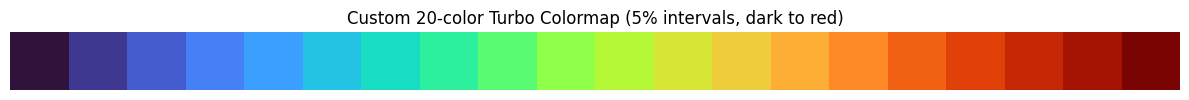

In [ ]:
# ── Custom 20-color Turbo Colormap (reusable for all plots) ──────────────────


# Create 20 evenly-spaced colors from turbo colormap (5% intervals: 0%, 5%, ..., 95%)
turbo_base = cm.get_cmap('turbo')
positions = np.linspace(0, 1, 20)
turbo_colors = [turbo_base(pos) for pos in positions]

# Create a reusable ListedColormap object for other plots
turbo_20 = ListedColormap(turbo_colors, name='turbo_20')

# Display the colormap
fig, ax = plt.subplots(figsize=(12, 2))
for i, (pos, color) in enumerate(zip(positions, turbo_colors)):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))
ax.set_xlim(0, 20)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Custom 20-color Turbo Colormap (5% intervals, dark to red)')
plt.tight_layout()
plt.show()

# Print RGB values
# print("\nCustom turbo_20 colormap created with 20 evenly-spaced colors:")
# print("Color values (RGBA):")
# for i, (pos, color) in enumerate(zip(positions, turbo_colors)):
#    print(f"{i+1:2d}. {pos*100:3.0f}%: rgba({color[0]:.3f}, {color[1]:.3f}, {color[2]:.3f}, {color[3]:.3f})")
# print(f"\n✓ Reusable colormap 'turbo_20' is now available for use in other plots")

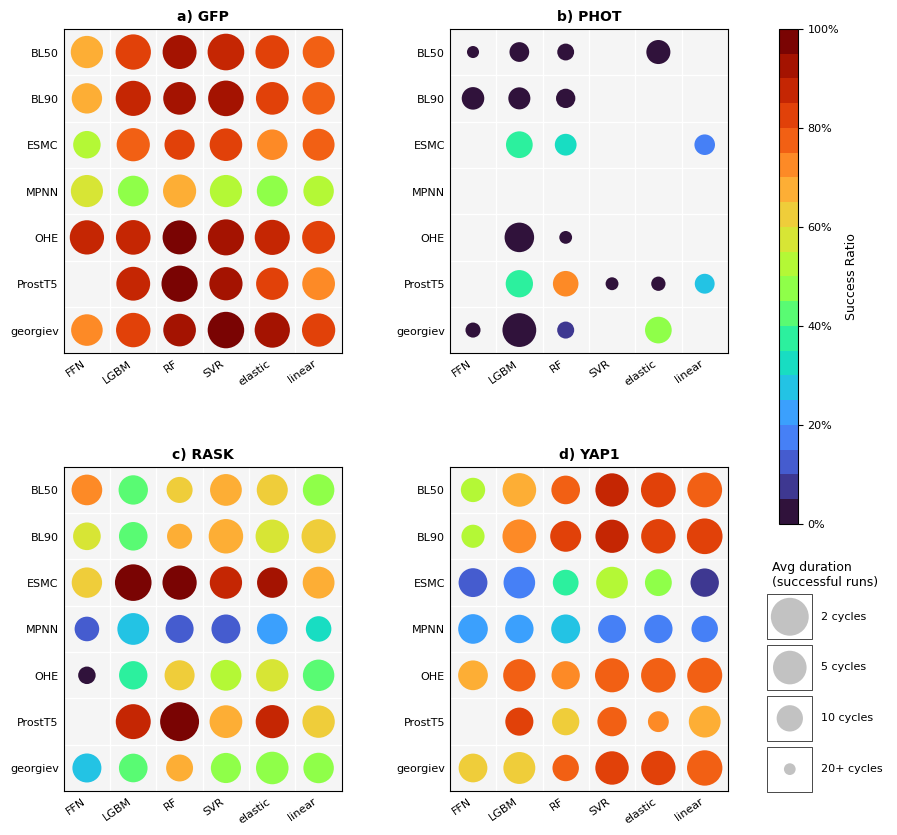

In [ ]:

# --- Custom Legend Handler ---
class BoxedCircleHandler(HandlerBase):
    def __init__(self, radius, **kwargs):
        self.radius = radius
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height,
                       fontsize, trans):

        # Force square box center logic
        cx = width / 2.0
        cy = height / 2.0
        
        BG = "white"

        # Fixed typo: 'acecolor' -> 'facecolor'
        box = Rectangle(
            (-xdescent, -ydescent),
            width, height,
            facecolor=BG,
            edgecolor="black",
            linewidth=0.5,
            transform=trans
        )

        # Scale circle radius relative to the legend handle box
        r_px = self.radius * width
        circle = Circle(
            (cx - xdescent, cy - ydescent),
            radius=r_px,
            facecolor=orig_handle.get_markerfacecolor(),
            edgecolor="none",
            alpha=0.7,
            transform=trans
        )

        return [box, circle]

# --- Global Config & Setup ---

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Note: Ensure 'runs_df' is defined in your environment before running this.
# For example: runs_df = pd.read_csv("your_data.csv")

datasets   = sorted(runs_df["dataset"].unique())
models     = sorted(runs_df["model"].unique())
embeddings = sorted(runs_df["embedding"].unique())

cmap = turbo_20
norm_c = mcolors.Normalize(vmin=0, vmax=1)

# --- Global duration normalization ---
all_avg_durations = []
for dataset in datasets:
    for embedding in embeddings:
        for model in models:
            s = runs_df[
                (runs_df["dataset"]   == dataset) &
                (runs_df["model"]     == model) &
                (runs_df["embedding"] == embedding) &
                (runs_df["status"]    == "finished") &
                (runs_df["result"]    == "success")
            ]
            if len(s) > 0:
                all_avg_durations.append(s["last_cycle"].mean())

min_dur = float(np.min(all_avg_durations)) if all_avg_durations else 1.0
max_dur = float(np.max(all_avg_durations)) if all_avg_durations else 40.0

if np.isclose(min_dur, max_dur):
    max_dur = min_dur + 1e-9

size_cap_dur = 20.0
upper_dur = min(max_dur, size_cap_dur) if min_dur < size_cap_dur else (min_dur + 1e-9)

def duration_to_radius(avg_dur, r_min=0.13, r_max=0.42):
    if avg_dur >= upper_dur:
        return r_min
    norm = (avg_dur - min_dur) / (upper_dur - min_dur)
    norm = np.clip(norm, 0.0, 1.0)
    return r_max - norm * (r_max - r_min)

# --- Figure layout ---
n_rows, n_cols = 2, 2
cell_size = 0.55
fig_width  = len(models) * cell_size * n_cols + 2.8
fig_height = len(embeddings) * cell_size * n_rows + 2.2

heatmap_overview, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
#fig.suptitle("Success Ratio per Model–Embedding Combination", fontsize=11, fontweight="bold", y=0.96)

positions = [(0,0), (0,1), (1,0), (1,1)]

# --- Plot panels ---
for idx, dataset in enumerate(datasets):
    if idx >= 4: break # Safety for 2x2 grid
    r, c = positions[idx]
    ax = axes[r][c]
    alpha_label = ["a", "b", "c", "d"][idx]

    for i, emb in enumerate(embeddings):
        for j, mdl in enumerate(models):
            fin = runs_df[(runs_df["dataset"] == dataset) & (runs_df["model"] == mdl) & (runs_df["embedding"] == emb) & (runs_df["status"] == "finished")]
            suc = fin[fin["result"] == "success"]

            # Background cell

            if len(fin) == 0 or len(suc) == 0:
                continue

            success_ratio = len(suc) / len(fin)
            avg_dur = suc["last_cycle"].mean()
            r_circle = duration_to_radius(avg_dur)
            color = cmap(norm_c(success_ratio))

            ax.add_patch(Circle((j, i), radius=r_circle, facecolor=color, edgecolor="none", zorder=2))

    ax.set_xlim(-0.5, len(models) - 0.5)
    ax.set_ylim(len(embeddings) - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(len(models)))
    ax.set_yticks(range(len(embeddings)))
    ax.set_xticklabels(models, rotation=35, ha="right")
    ax.set_yticklabels(embeddings)
    ax.set_title(f"{alpha_label}) {dataset}", pad=6, fontweight="bold")
    ax.tick_params(axis='both', which='both', length=0)

    # Draw cell grid lines (between integer positions)
    ax.set_facecolor('#f5f5f5')
    for gx in range(-1, len(models)):
        ax.axvline(gx + 0.5, color='white', linewidth=1.0, zorder=1)
    for gy in range(-1, len(embeddings)):
        ax.axhline(gy + 0.5, color='white', linewidth=1.0, zorder=1)

# --- Colorbar ---
heatmap_overview.subplots_adjust(right=0.84, wspace=0.35, hspace=0.35)
cbar_ax = heatmap_overview.add_axes([0.89, 0.38, 0.02, 0.50])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
cbar = heatmap_overview.colorbar(sm, cax=cbar_ax)
cbar.set_label("Success Ratio", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# --- Bubble size legend ---
legend_durations = [2, 5, 10, size_cap_dur]
legend_labels = [f"{d:.0f} cycles" for d in legend_durations]
if max_dur > size_cap_dur: legend_labels[-1] = f"{size_cap_dur:.0f}+ cycles"

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='darkgray', 
           markeredgecolor='none', label=lbl)
    for lbl in legend_labels
]

# Map the custom handler to the handles
handler_map = {h: BoxedCircleHandler(radius=duration_to_radius(d)) 
               for h, d in zip(legend_handles, legend_durations)}

heatmap_overview.legend(handles=legend_handles, 
    handler_map=handler_map,
    title="Avg duration\n(successful runs)",
    loc="upper left",
    bbox_to_anchor=(0.867, 0.353),
    frameon=False,
    fontsize=8,
    handlelength=4.06,
    handleheight=4.06*1.45
)

plt.show()

# ── Save ───────────────────────────────────────────────────────────────────
outpath = "plots/combined_heatmaps/"
heatmap_overview.savefig(os.path.join(outpath, "heatmap_overview.jpg"), dpi=600, bbox_inches="tight")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# Using the pca_df which already has 'success' and one-hot encoded variables
X_rf = pca_df.drop(columns=['success', 'last_cycle', 'run'], errors='ignore') # dropping run as it's an arbitrary index
y_rf = pca_df['success'] if 'success' in pca_df.columns else None

if y_rf is not None:
    # Initialize and fit Random Forest
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_rf, y_rf)

    # Extract feature importances
    importances = rf_classifier.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': X_rf.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

    # Calculate grouped importances to answer your specific questions
    grouped_imp = {
        'n_Start': feat_imp_df[feat_imp_df['Feature'] == 'n_Start']['Importance'].sum(),
        'n_Gain': feat_imp_df[feat_imp_df['Feature'] == 'n_Gain']['Importance'].sum(),
        'Models (Total)': feat_imp_df[feat_imp_df['Feature'].str.startswith('model_is')]['Importance'].sum(),
        'Embeddings (Total)': feat_imp_df[feat_imp_df['Feature'].str.startswith('embedding_is')]['Importance'].sum(),
        'Datasets (Total)': feat_imp_df[feat_imp_df['Feature'].str.startswith('dataset_is')]['Importance'].sum(),
    }
    
    group_imp_df = pd.DataFrame(list(grouped_imp.items()), columns=['Category', 'Total Importance']).sort_values(by='Total Importance', ascending=False)

    # Plot the results using Plotly
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Top 15 Individual Feature Importances', 'Combined Feature Importance by Category'))

    fig.add_trace(go.Bar(
        x=feat_imp_df.head(15)['Importance'],
        y=feat_imp_df.head(15)['Feature'],
        orientation='h',
        marker=dict(color=feat_imp_df.head(15)['Importance'], colorscale='turbo'),
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=group_imp_df['Total Importance'],
        y=group_imp_df['Category'],
        orientation='h',
        marker=dict(color=group_imp_df['Total Importance'], colorscale='turbo'),
        showlegend=False
    ), row=1, col=2)

    fig.update_layout(
        title="Predictive Importance for Success (All Datasets)",
        paper_bgcolor='rgb(233,233,233)',
        plot_bgcolor='rgb(233,233,233)',
        showlegend=False
    )
    
    # Apply grid styles (similar to duration_plt)
    fig.update_xaxes(
        title_text="Importance",
        showgrid=True, gridcolor='lightgrey', griddash="dot", minor_griddash="dot", zerolinecolor='black'
    )
    # Autorange reversed keeps the top importance at the top of the horizontal bar chart
    fig.update_yaxes(
        autorange="reversed",
        showgrid=True, gridcolor='lightgrey', griddash="dot", minor_griddash="dot", zerolinecolor='black'
    )

    fig.show()

    # Console Output with Direct Answers
    print("====== PREDICTIVE IMPORTANCE FOR SUCCESS ======\n")
    print(f"1. n_Start vs n_Gain:")
    print(f"   - n_Start impact: {grouped_imp['n_Start']:.4f}")
    print(f"   - n_Gain impact:  {grouped_imp['n_Gain']:.4f}")
    if grouped_imp['n_Start'] > grouped_imp['n_Gain']:
        print("   -> 'n_Start' size has a larger impact on success than 'n_Gain'.\n")
    else:
        print("   -> 'n_Gain' size has a larger impact on success than 'n_Start'.\n")

    print(f"2. Model vs Embedding:")
    print(f"   - Total Model Choice impact:     {grouped_imp['Models (Total)']:.4f}")
    print(f"   - Total Embedding Choice impact: {grouped_imp['Embeddings (Total)']:.4f}")
    if grouped_imp['Models (Total)'] > grouped_imp['Embeddings (Total)'] * 1.5:
        print("   -> The applied Model is highly dominant over the Embedding.\n")
    elif grouped_imp['Embeddings (Total)'] > grouped_imp['Models (Total)'] * 1.5:
        print("   -> The applied Embedding is highly dominant over the Model.\n")
    else:
        print("   -> Model and Embedding choice contribute somewhat similarly to success.\n")
        
    print(f"3. Most Critical Individual Feature Overlay:")
    print(f"   - Feature: '{feat_imp_df.iloc[0]['Feature']}' accounts for {feat_imp_df.iloc[0]['Importance']:.2%} of the variance in success.")

====== PREDICTIVE IMPORTANCE FOR SUCCESS ======

1. n_Start vs n_Gain:
   - n_Start impact: 0.1132
   - n_Gain impact:  0.1796
   -> 'n_Gain' size has a larger impact on success than 'n_Start'.

2. Model vs Embedding:
   - Total Model Choice impact:     0.0888
   - Total Embedding Choice impact: 0.1849
   -> The applied Embedding is highly dominant over the Model.

3. Most Critical Individual Feature Overlay:
   - Feature: 'dataset_is_PHOT' accounts for 22.46% of the variance in success.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Use YAP1 specific dataframe we already have
yap1_df = runs_df[(runs_df['dataset'] == 'YAP1') 
                    &(runs_df['status'] == 'finished') 
                    #&(runs_df['n_Start'].isin([3000]))
                    &(runs_df['n_Gain'].isin([100]))
                    ].copy()

# Ensure we encode combination as our target "feature"
# Or instead, treat "embedding" and "model" as features 
# to figure out which combo works best.
le_emb = LabelEncoder()
le_mod = LabelEncoder()
yap1_df['emb_encoded'] = le_emb.fit_transform(yap1_df['embedding'])
yap1_df['mod_encoded'] = le_mod.fit_transform(yap1_df['model'])

# Our target variable: Did it succeed?
yap1_df['target'] = (yap1_df['result'] == 'success').astype(int)

# Optional: also include n_Start and n_Gain as features
yap1_df['n_Start'].fillna(yap1_df['n_Start'].median(), inplace=True)
yap1_df['n_Gain'].fillna(yap1_df['n_Gain'].median(), inplace=True)

X = yap1_df[['emb_encoded', 'mod_encoded', 'n_Start', 'n_Gain']]
y = yap1_df['target']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
features = X.columns
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")

# Since the user specifically asked for "which combination ... works best",
# let's calculate average success rate per combination for YAP1.
# Also including duration as requested
yap1_success_df = yap1_df[yap1_df['result'] == 'success']
duration_agg = yap1_success_df.groupby(['embedding', 'model'])['last_cycle'].mean().rename('avg_duration')

combo_success = yap1_df.groupby(['embedding', 'model'])['target'].agg(['mean', 'count']).reset_index()
combo_success = combo_success.rename(columns={'mean': 'success_rate', 'count': 'num_runs'})

# Merge duration back into the success table
combo_success = combo_success.merge(duration_agg, on=['embedding', 'model'], how='left')
combo_success['avg_duration'] = combo_success['avg_duration'].fillna(0)
combo_success = combo_success.sort_values(by=['success_rate', 'avg_duration'], ascending=[False, True])

display(combo_success)

emb_encoded: 0.4159
mod_encoded: 0.3251
n_Start: 0.2590
n_Gain: 0.0000


/tmp/ipykernel_34797/2133699297.py:24: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_34797/2133699297.py:25: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)

,embedding,model,success_rate,num_runs,avg_duration
34,ProstT5,linear,1.000000,42,4.238095
30,ProstT5,LGBM,1.000000,47,4.276596
32,ProstT5,SVR,1.000000,50,4.300000
26,OHE,RF,1.000000,36,5.250000
31,ProstT5,RF,1.000000,37,6.081081
33,ProstT5,elastic,1.000000,50,12.160000
8,BL90,RF,0.956522,46,3.590909
37,georgiev,RF,0.954545,44,5.000000
2,BL50,RF,0.931818,44,3.756098
3,BL50,SVR,0.918367,49,2.200000
